# Nitrogen analysis

We analyze the effect of fertilizer on maize crop yield using the Double Machine Learning method (DML). Under the DML structural equation model, and being treatment a continuous variable, the effect of fertilizer is functionally equivalent to the fertilizer Agronomic Efficiency (AE). We will address the question **what is the effect of fertilizer on maize yield** considering the next effect modifier factors:
- Soil type, i.e. sandy or non-sandy.
- Fertilizer timing, i.e. how it was split through the season.
- Fertilizer amount itself, i.e. the fertilizer response curve.
- Using a NP blend.
- Having a history of maize-legume rotation

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl
plt.style.use('../publication.mplstyle') # mpl style for publication-quality figures
# Modify cycler palette
plt.rcParams['axes.prop_cycle'] = mpl.cycler(
    'color', ('#E66100', '#5D3A9B', '#E1BE6A', '#40B0A6', '#1A85FF', '#D41159')
)  

import pickle
import geopandas as gpd

In [2]:
from CAgsalML.tuning import GPOptimizer
from CAgsalML.transformers import SpatialTransform

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import  r2_score
from sklearn.model_selection import  cross_val_predict
from skopt.space import Categorical, Integer, Real

In [4]:
RANDOM_SEED = 43
np.random.seed(RANDOM_SEED)
import random
random.seed(RANDOM_SEED)

# Adjust data

In [5]:
DATA_VERSION = '260116'
DATA_PATH = "/data/mba-tza"
data = pd.read_pickle(f'{DATA_PATH}/processed/data-dag-{DATA_VERSION}.pkl')
data = data.loc[data.crop_maize]  # Focus on maize only
adjustment_nodes = [
    # Minimal optimal adjustment set
    'fertilizerTiming', 'accessibilityRAI', 'soil', 
    'investmentCap', 
    'fieldHistory', 'fertilizerAmountP'
]
columns_dict = { # Includes all nodes, not only adjustment nodes
    'fertilizerAmountP': ['fertP_total'],
    'fertilizerAmountN': ['fertN_total'],
    'fieldHistory': [
        'fieldsize_value',  'history_maize', 'history_nocrop', 'history_legume',
        'history_rootandtuber', 'history_oilseed', 'history_maizelegume'
    ],
    'soil': [
        'soilfert_cec', 'soilfert_oc', 'soilpp_clay',
        'soilpp_density', 'soilpp_sand', 'soil_sandy'
    ],
    'outcome': ['outcome_prodstd'],
    'fertilizerTiming': [
        'fertN_56leaves', 'fertN_810leaves', 'fertN_basal', 
        'fertN_kneehigh','fertN_tasselingsilking', 'fertP_56leaves',
        'fertP_810leaves', 'fertP_basal', 'fertP_kneehigh',
        'fertP_tasselingsilking'
    ],
    'otherManagement': [
       'herbicide_post', 'herbicide_pre', 'herbicide_any', 'manure_any',
       'planting_handhoe', 'planting_ploughsowing', 'planting_string',
       'residue_burn', 'residue_feedtoanimals', 'residue_incorporateinthesoil',
       'residue_leaveonfield', 'residue_onfield'
    ],
    'variety': ['variety_hybrid', 'variety_recycled'],
    'accessibilityRAI': ['accessibility_rai'],
    'investmentCap': ['investing_capacity_index']
}
assert all(i in columns_dict for i in adjustment_nodes)
outcome_name = 'outcome_prodkgha'
treatment_name = 'fertN_total'
# Bad controls. All nodes that are not in the adjustment set.
bad_controls = [
    i for c in sorted(set(columns_dict) - set(adjustment_nodes)) 
    for i in columns_dict[c]
]
features = [i for v in columns_dict.values() for i in v]
features = list(sorted(
    list(set(features) - set(bad_controls) - {outcome_name, treatment_name})
))

# Import geometries.
crs = 'EPSG:32736'
points = gpd.read_file(f'{DATA_PATH}/geo/points.geojson')
points = points.set_index('fieldID')[['geometry']]
points = points.loc[data.index]
points = points.to_crs(crs)
admin = gpd.read_file(f'{DATA_PATH}/geo/tza_shp/tza_admbnda_adm3_20181019.shp')
admin = admin.to_crs(crs)

# Perform a spatial join to assign ADM3_PCODE and ADM2_PCODE to each point
points = gpd.sjoin(
    points, admin[['ADM3_PCODE', 'ADM2_PCODE', 'geometry']], 
    how="left", predicate="within"
)
points = points.drop(columns=['index_right'])
# There is only a few points there, then I'll move then to the neighboring unit
points['ADM2_PCODE'] = points['ADM2_PCODE'].replace({'TZ2610': 'TZ2609'}) 

# This is the data before transforming it for DAG, just in case
clean_data = pd.read_pickle(f'{DATA_PATH}/processed/maize-soya-clean-{DATA_VERSION}.pkl')

# Get indexes for the subset of data we are interested in. We will use all data, 
# this is defined just in case. 
index_zone_subset = data.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]

In [6]:
# Assign to 0 all the stage-specific fertilizer amounts if the total is zero
data.loc[data.fertP_total == 0, data.filter(like='fertP').columns] = 0
data.loc[data.fertN_total == 0, data.filter(like='fertN').columns] = 0
data = data.loc[data.fertN_total > 0]

In [7]:
TIMINGS = [ # We don't include emergence, as it will be merged to basal
    'basal', 'kneehigh', '56leaves', '810leaves',
    'tasselingsilking'
]
# Check the variability of amounts.
data.loc[:, [f'fertN_{t}' for t in TIMINGS]].describe()

,fertN_basal,fertN_kneehigh,fertN_56leaves,fertN_810leaves,fertN_tasselingsilking
count,1791.000000,1786.000000,1786.000000,1786.000000,1786.000000
mean,0.158447,0.073174,0.346398,0.404195,0.020142
std,0.210621,0.218476,0.318844,0.316239,0.113795
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.095238,0.000000,0.381743,0.431120,0.000000
75%,0.272110,0.000000,0.552147,0.676647,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
T_series = data[treatment_name]
Y_series = data[outcome_name]

transformed_data = pd.DataFrame(index=data.index)
# Normalize features
numeric_features = list(data[features].select_dtypes(include='number').columns)
numeric_features = list(sorted(set(numeric_features).intersection(features)))
dummy_features = set((data.loc[:, data.isin([0, 1]).all()].columns))
dummy_features = dummy_features - set(numeric_features)
dummy_features = list(sorted(dummy_features.intersection(features)))
timing_features = [f'fertN_{t}' for t in TIMINGS[:]]

numeric_features = list(sorted(
    (set(numeric_features) - set(dummy_features)) - set(timing_features)
))

transformed_data[numeric_features] = StandardScaler().fit_transform(
    data[numeric_features]
).astype(np.float32)
transformed_data[dummy_features] = data[dummy_features].astype(float)
transformed_data[timing_features] = data[timing_features]

# Select only features and Drop those rows with no outcome
transformed_data = transformed_data[features]
transformed_data = transformed_data.loc[data[outcome_name].dropna().index]

# Drop rows with values not within a feasible range
NORMALIZED_LIM = 5
transformed_data = transformed_data.loc[
    (transformed_data < NORMALIZED_LIM).all(axis=1) & 
    (transformed_data > -NORMALIZED_LIM).all(axis=1)
]
# Redefine index of samples
index_zone_subset = transformed_data.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]
transformed_data.shape

(1709, 26)

## Spatial demeaning of outcome and treatment

In [9]:
# The DML pipeline includes a demeaning step, then the nuisance functions
# will predict the demeaned variable. Thus, the spatially demeaned outcomes and 
# treatments will be used to select the ML models.

# Spatially demean the outcome
spatial_transformer_yield = SpatialTransform(
    points.geometry, maxlag=50e3, esitmator='cressie',
    model='matern', n_lags=50, use_nugget=True
)
spatial_transformer_yield.fit(data.loc[transformed_data.index, outcome_name])
demeaned_outcome = pd.Series(
    spatial_transformer_yield.transform_demean(), index=transformed_data.index
)
# Spatially demean the treatment
spatial_trans_index = points.index
spatial_transformer_fertilizer = SpatialTransform(
    points.geometry, maxlag=50e3, esitmator='cressie',
    model='matern', n_lags=50, use_nugget=True
)
spatial_transformer_fertilizer.fit(data.loc[transformed_data.index, treatment_name])
demeaned_treatment = pd.Series(
    spatial_transformer_fertilizer.transform_demean(), index=transformed_data.index
)
nona_t_and_y_index = demeaned_treatment.dropna().index.intersection(demeaned_outcome.dropna().index)
demeaned_treatment = demeaned_treatment.loc[nona_t_and_y_index]
demeaned_outcome = demeaned_outcome.loc[nona_t_and_y_index]

In [10]:
# Keep only complete records
transformed_data = transformed_data.dropna()
transformed_data = transformed_data.loc[nona_t_and_y_index]
index_zone_subset = transformed_data.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]
transformed_data.shape

(1707, 26)

## Group indicators

### Timing indicators

In [11]:
appl_clusters_df = pd.DataFrame(transformed_data[timing_features], columns=timing_features)

In [12]:
def assign_timing_strategy(row):
        basal = False
        n_tops = 0
        basal = row['fertN_basal'] > 0
        n_tops = (row[['fertN_kneehigh', 'fertN_56leaves', 'fertN_810leaves', 'fertN_tasselingsilking']] > 0).sum()
        if not basal:
            return "Top-Only"
        elif n_tops < 1:
            return "Basal-Only"
        elif n_tops == 1:
            return "Basal+Single"
        else:
            return "Basal+Split"

appl_clusters_df["Cluster name"] = appl_clusters_df.apply(assign_timing_strategy, axis=1)

In [13]:
# How many samples where a single application timing was used
(appl_clusters_df.iloc[:, :5] > .99).any(axis=1).sum()

np.int64(294)

In [14]:
appl_clusters_df['Cluster name'].value_counts()

Cluster name
Top-Only        837
Basal+Single    540
Basal+Split     300
Basal-Only       30
Name: count, dtype: int64

### P-Fertilizer indicator

In [15]:
# Look at basal types used to explore how to include the use of P-fertilizer as 
# an effect modifier term.
basal_types_count = pd.Series(
    clean_data[['basaltypes', 'top1types']]
    .fillna('')
    .applymap(lambda x: x.split())
    .applymap(list).sum(axis=1).sum()
).value_counts()
basal_types_count = basal_types_count.to_frame()
basal_types_count

,count
Urea,1262
DAP,1094
SA,841
Bela-CAN26,299
NPS,28
NPSZinc,25
CAN27-OCP,19
Yara-Vera-Amidas,11
Yara-Mila-Cereal,4
Yara-Mila-OTESHA,3


In [16]:
# We will look out the NPK content of each fertilizer
basal_types_count[['N', 'P', 'K']] = np.nan
basal_types_count.loc['Urea', ['N', 'P', 'K']] = (46, 0, 0)
basal_types_count.loc['DAP', ['N', 'P', 'K']] = (18, 46, 0)
basal_types_count.loc['SA', ['N', 'P', 'K']] = (21, 0, 0)
basal_types_count.loc['Bela-CAN26', ['N', 'P', 'K']] = (26, 0, 0)
basal_types_count.loc['NPS', ['N', 'P', 'K']] = (19, 38, 0)
basal_types_count.loc['NPSZinc', ['N', 'P', 'K']] = (19, 38, 0)
basal_types_count.loc['CAN27-OCP', ['N', 'P', 'K']] = (27, 0, 0)
basal_types_count.loc['Yara-Vera-Amidas', ['N', 'P', 'K']] = (40, 0, 0)
basal_types_count.loc['Yara-Mila-Cereal', ['N', 'P', 'K']] = (23, 10, 5)
basal_types_count.loc['Yara-Mila-OTESHA', ['N', 'P', 'K']] = (13, 24, 12)
basal_types_count.loc['Yara-Bela-Sulfan', ['N', 'P', 'K']] = (24, 0, 0)
basal_types_count.loc['NPK-20|10|10', ['N', 'P', 'K']] = (20, 10, 10)
basal_types_count.loc['NPK-14|23|14', ['N', 'P', 'K']] = (14, 23, 14)
basal_types_count

,count,N,P,K
Urea,1262,46.0,0.0,0.0
DAP,1094,18.0,46.0,0.0
SA,841,21.0,0.0,0.0
Bela-CAN26,299,26.0,0.0,0.0
NPS,28,19.0,38.0,0.0
NPSZinc,25,19.0,38.0,0.0
CAN27-OCP,19,27.0,0.0,0.0
Yara-Vera-Amidas,11,40.0,0.0,0.0
Yara-Mila-Cereal,4,23.0,10.0,5.0
Yara-Mila-OTESHA,3,13.0,24.0,12.0


In [17]:
# Based on the Fertilizer type count, we will define four P-fertilizer groups: 
# N-Only, DAP fertilizer, NPS fertilizer, and other NP-fertilizers
p_types_dict = {
    'DAP': ['DAP'],
    'Other-NP': [
        'Yara-Mila-Cereal', 'Yara-Mila-OTESHA', 'NPK-20|10|10', 
        'NPK-14|23|14', 'NPS', 'NPSZinc'
    ]
}
def assign_p_fertilizer_group(row):
    basal_types = row['basaltypes'].split() if pd.notna(row['basaltypes']) else []
    top1types = row['top1types'].split() if pd.notna(row['top1types']) else []
    all_types = basal_types + top1types
    types = []
    for group, fertilizers in p_types_dict.items():
        if any(fert in all_types for fert in fertilizers):
            types.append(group)
    if types == []:
        return 'N-Only'
    elif len(types) > 1:
        return 'Other-NP'
    else:
        return types[0]

p_fertilizer_groups = clean_data.apply(assign_p_fertilizer_group, axis=1)
p_fertilizer_groups = p_fertilizer_groups.loc[transformed_data.index]
p_fertilizer_groups.value_counts()

DAP         906
N-Only      747
Other-NP     54
Name: count, dtype: int64

### Crop rotation indicator

In [18]:
legume_rotation_groups = transformed_data.loc[:, ['history_maizelegume']].astype(bool).map(lambda x: {
    False: 'Non-Legume', True: 'Legume'
}.get(x))

## Add the group-indicators variables
The group indicator variables for timing cluster, and P-fertilizer type are added to the data 

In [19]:
# Add the timing dummies and p-fertilizer dummies to the data. Note that the noise dummy is not added
timing_dummies = pd.get_dummies(appl_clusters_df['Cluster name'], prefix='timing', drop_first=False).astype(int)
p_fertilizer_dummies = pd.get_dummies(p_fertilizer_groups, prefix='pfertilizer', drop_first=False).astype(int)
transformed_data = pd.concat([transformed_data, timing_dummies, p_fertilizer_dummies], axis=1)
features.extend(timing_dummies.columns)
features.extend(p_fertilizer_dummies.columns)
# Legume dummies are not added as they have the same exact information as history_legume

In [20]:
transformed_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
accessibility_rai,1707.0,-0.004398,0.989481,-2.576496,-0.609129,-0.434983,1.397597,1.397597
fertN_56leaves,1707.0,0.355013,0.317745,0.000000,0.000000,0.400278,0.552147,1.000000
fertN_810leaves,1707.0,0.401728,0.309996,0.000000,0.000000,0.432161,0.666667,1.000000
fertN_basal,1707.0,0.156036,0.203269,0.000000,0.000000,0.109756,0.268810,1.000000
fertN_kneehigh,1707.0,0.070306,0.214962,0.000000,0.000000,0.000000,0.000000,1.000000
fertN_tasselingsilking,1707.0,0.016918,0.102156,0.000000,0.000000,0.000000,0.000000,1.000000
fertP_56leaves,1707.0,0.002442,1.006807,-0.345564,-0.345564,-0.345564,-0.345564,3.052455
fertP_810leaves,1707.0,-0.108518,0.470606,-0.176930,-0.176930,-0.176930,-0.176930,4.310733
fertP_basal,1707.0,0.012063,1.005220,-0.888457,-0.888457,-0.888457,1.155952,1.155952
fertP_kneehigh,1707.0,-0.084448,0.148744,-0.089541,-0.089541,-0.089541,-0.089541,4.257234


# Effect estimation pipeline

## Generalized propensity score

In [21]:
x_names = list(timing_dummies.columns)
x_names += list(p_fertilizer_dummies.columns)
w_names = list(sorted(set(features) - set(x_names)))

# training_idxs, testing_idxs = train_test_split(index_zone_subset, random_state=RANDOM_SEED, train_size=1)
testing_idxs = [] 
training_idxs = index_zone_subset # Use all for training and rely on CV 
print(f"{len(training_idxs)} training samples")
print(f"{len(testing_idxs)} testing samples")
print(f'N features: {len(x_names)+len(w_names)}')

1707 training samples
0 testing samples
N features: 33


In [22]:
# First we need a model for the treatment
X_train = transformed_data.loc[training_idxs, w_names + x_names]
t_train = demeaned_treatment.loc[training_idxs]

optimizer_treatment = GPOptimizer(
    model=RandomForestRegressor,
    model_kwargs=dict(
        max_depth=Integer(name='max_depth', low=2, high=10),
        max_features=Categorical(name='max_features', categories=['sqrt', 'log2']),
        min_samples_leaf=Integer(name='min_samples_leaf', low=1, high=50),
        n_estimators=100, random_state=RANDOM_SEED
    )
)

model_treatment, cv_scores_treatment = optimizer_treatment.cv_optimize(
    X_train, t_train,
    cv=5,
    cv_kwargs=dict(n_jobs=-1, scoring='r2'),
    gp_kwargs=dict(n_calls=50, n_initial_points=5, verbose=False, random_state=RANDOM_SEED)
)
print(f"Best hyperparameters for treatment model:\n{model_treatment}")
print(f"R2 = {np.mean(cv_scores_treatment):.4f} (+/- {np.std(cv_scores_treatment):.4f})")

Best hyperparameters for treatment model:
RandomForestRegressor(max_depth=np.int64(10), max_features=np.str_('sqrt'),
                      min_samples_leaf=np.int64(1), random_state=43)
R2 = 0.2325 (+/- 0.0509)


In [23]:
model_treatment = model_treatment.fit(X_train, t_train)
pd.Series(
    model_treatment.feature_importances_,
    index=features
).sort_values(ascending=False).head(10)

fertP_total                 0.127384
fieldsize_value             0.095370
fertN_56leaves              0.089688
fertN_810leaves             0.071856
fertN_basal                 0.066950
investing_capacity_index    0.060257
soilpp_clay                 0.058092
soilpp_density              0.055980
soilpp_sand                 0.053449
soilfert_oc                 0.051006
dtype: float64

<Axes: ylabel='Count'>

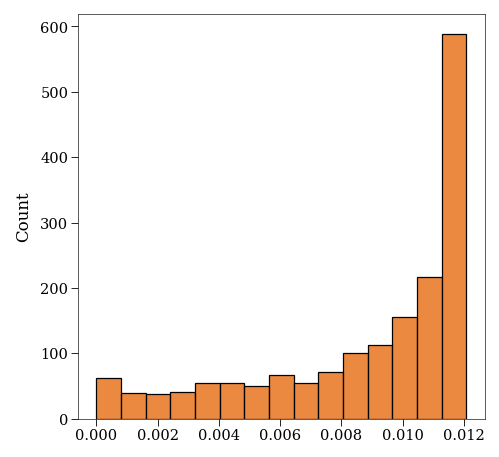

In [24]:
from scipy import stats
# Use Zhu et al. (2018) and Hirano and Gimbens (2004) approach to estimate PS for continuous treatments
T = demeaned_treatment.values
# Get the CV predictions to estimate the variance of residuals
T_pred = cross_val_predict(
    model_treatment, 
    X=transformed_data.loc[:, w_names + x_names],
    y=demeaned_treatment,
)
T_res = T - T_pred
res_var = np.var(T_res)

# Estimate the GPS
# gps = (1/(np.sqrt(2*np.pi*res_var)))*np.exp((-1/(2*res_var))*treatment_res**2)
gps_density = stats.norm.pdf(
    T, 
    loc=T_pred, 
    scale=res_var**.5 # Scale is sd in this function
)
sns.histplot(gps_density)

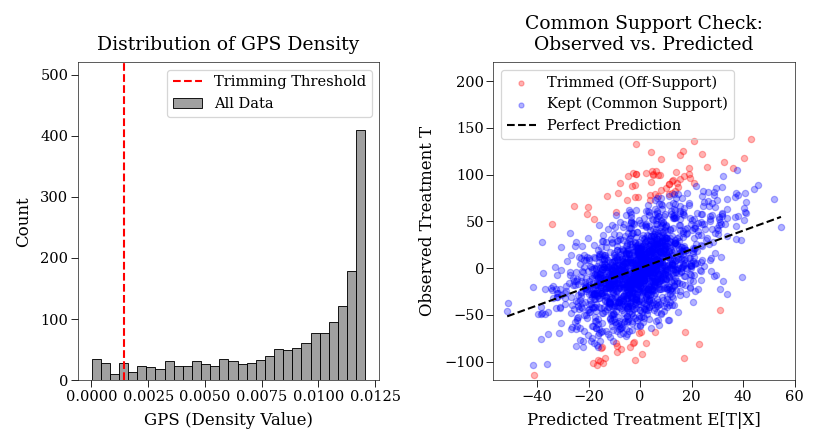

In [25]:
threshold = np.quantile(gps_density, 0.05)
mask_support = gps_density >= threshold
fig, axes = plt.subplots(1, 2, figsize=(5.5, 3))
ax = axes[0]

sns.histplot(gps_density, bins=30, ax=axes[0], color='grey', label='All Data')
ax.axvline(threshold, color='red', linestyle='--', label='Trimming Threshold')
ax.set_title("Distribution of GPS Density")
ax.set_xlabel("GPS (Density Value)")
ax.legend()
ax.set_ylim(0, 520)

ax = axes[1]
ax.scatter(T_pred[~mask_support], T[~mask_support], alpha=0.3, color='red', label='Trimmed (Off-Support)')
ax.scatter(T_pred[mask_support], T[mask_support], alpha=0.3, color='blue', label='Kept (Common Support)')
ax.plot([min(T_pred), max(T_pred)], [min(T_pred), max(T_pred)], 'k--', lw=1, label='Perfect Prediction')

ax.set_title("Common Support Check:\nObserved vs. Predicted")
ax.set_xlabel("Predicted Treatment E[T|X]")
ax.set_ylabel("Observed Treatment T")
ax.legend(loc='upper left', facecolor='none')
ax.set_ylim(-120, 220)
# ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
fig.savefig(f'{DATA_PATH}/results/figures/N-fertilizer-gps-support.pdf', bbox_inches='tight', dpi=300)

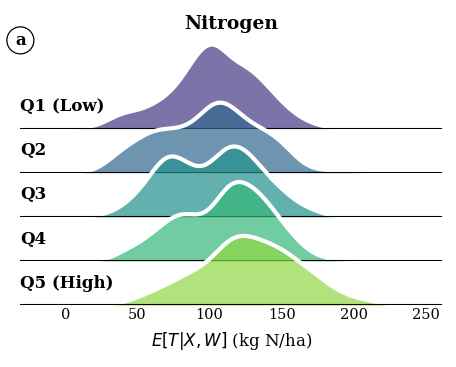

In [26]:
spatial_t = spatial_transformer_fertilizer.predict()
spatial_t = spatial_t[~np.isnan(spatial_t)] 
ps_df = pd.DataFrame({
    'T_pred': (T_pred + spatial_t)[mask_support], 
    'Strata': pd.qcut(T[mask_support], 5, labels=False)
}, index=transformed_data.iloc[mask_support].index)

g = sns.FacetGrid(ps_df, row="Strata", hue="Strata", aspect=7, height=.5, palette="viridis")
g.map(sns.kdeplot, "T_pred", clip_on=False, fill=True, alpha=0.7, lw=0)
g.map(sns.kdeplot, "T_pred", clip_on=False, color="w", lw=2)

g.fig.subplots_adjust(hspace=-.5)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
g.axes.flat[0].set_title("Nitrogen", fontweight='bold', y=.99) 
g.axes.flat[-1].set_xlabel(r'$E[T|X,W]$'+' (kg N/ha)')

# Optional: Add text labels for each stratum
for ax, label in zip(g.axes.flat, ["Q1 (Low)", "Q2", "Q3", "Q4", "Q5 (High)"]):
    ax.text(0, 0.2, label, fontweight="bold", transform=ax.transAxes)
    ax.axhline(0, color='k', linestyle="-")
    ax.set_facecolor('none')
    # ax.grid(None)
    ax.tick_params(length=0)

g.axes.flat[0].text(
    0, 1, 'a', transform=g.axes.flat[0].transAxes, va='center', ha='center', fontsize=8,
    fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
)


g.fig.savefig(f'{DATA_PATH}/results/figures/N-fertilizer-gps-support-strata.pdf', bbox_inches='tight', dpi=300)

In [27]:
# Trim extreme GPS values 
transformed_data_pstrimmed = transformed_data.copy()
transformed_data_pstrimmed = transformed_data_pstrimmed.loc[gps_density > threshold]

In [28]:
# Select the new subset of the data after PS-trimming
index_zone_subset = transformed_data_pstrimmed.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]
transformed_data_pstrimmed.shape

(1621, 33)

## Outcome model $q(X, W)$

In [29]:
# Re-select the training indexes based on the new subset from PS-trimming. 
training_idxs = training_idxs.intersection(index_zone_subset)
# testing_idxs = testing_idxs.intersection(index_zone_subset)
X_train = transformed_data_pstrimmed.loc[:, w_names + x_names]
t_train = demeaned_treatment.loc[training_idxs]
T = demeaned_treatment.loc[training_idxs].values

In [30]:
y_train = demeaned_outcome.loc[training_idxs]

optimizer_q = GPOptimizer(
    model=RandomForestRegressor,
    model_kwargs=dict(
        max_depth=Integer(name='max_depth', low=2, high=10),
        max_features=Categorical(name='max_features', categories=['sqrt', 'log2']),
        min_samples_leaf=Integer(name='min_samples_leaf', low=1, high=50),
        n_estimators=100, random_state=RANDOM_SEED
    )
)

model_q, cv_scores_q = optimizer_q.cv_optimize(
    X_train, y_train,
    cv=5,
    cv_kwargs=dict(n_jobs=-1, scoring='r2'),
    gp_kwargs=dict(n_calls=100, n_initial_points=5, verbose=False, random_state=RANDOM_SEED)
)
print(f"Best hyperparameters for outcome model:\n{model_q}")
print(f"R2 = {np.mean(cv_scores_q):.4f} (+/- {np.std(cv_scores_q):.4f})")

Best hyperparameters for outcome model:
RandomForestRegressor(max_depth=np.int64(10), max_features=np.str_('sqrt'),
                      min_samples_leaf=np.int64(9), random_state=43)
R2 = 0.0455 (+/- 0.0190)


In [31]:
model_q = model_q.fit(X_train, y_train)

In [32]:
pd.Series(
    model_q.feature_importances_,
    index=features
).sort_values(ascending=False).head(10)

fertP_total                 0.168194
fieldsize_value             0.104026
fertN_810leaves             0.081658
fertN_56leaves              0.076223
investing_capacity_index    0.073334
soilpp_clay                 0.073032
soilpp_density              0.065227
soilfert_oc                 0.062342
soilfert_cec                0.062341
soilpp_sand                 0.053582
dtype: float64

## Effect estimation with DML 

In [33]:
from econml.dml import LinearDML
from sklearn.preprocessing import SplineTransformer, PolynomialFeatures, add_dummy_feature
from sklearn.multioutput import MultiOutputRegressor

In [34]:
sandy_series = transformed_data_pstrimmed['soil_sandy'].to_numpy()
sandy_series.mean()

### Effect only Soil

In [35]:
# Homogeneous effect: Response curve is a line and it does not depend on timing
X_soil = np.vstack([~sandy_series.astype(bool), sandy_series]).T

dml_soil_features = list(filter(
    lambda x: not (x.startswith('timing') or x.startswith('pfertilizer')),
    features
))
W_soil = transformed_data_pstrimmed.loc[:, dml_soil_features]
Y = demeaned_outcome.loc[transformed_data_pstrimmed.index].to_numpy()
T = demeaned_treatment.loc[transformed_data_pstrimmed.index].to_numpy()

lineardml_only_soil = LinearDML(
    model_y=model_q, 
    model_t=model_treatment, 
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED, 
    fit_cate_intercept=False,
)
lineardml_only_soil = lineardml_only_soil.fit(
    Y=Y, T=T, W=W_soil, X=X_soil,
    inference='statsmodels', cache_values=True,
)
x_names_soil = ['Non-sandy', 'Sandy']
lineardml_only_soil.summary(feature_names=x_names_soil)

CATE Intercept Results:  No intercept was fitted!


,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
Non-sandy,12.421,1.666,7.457,0.0,9.156,15.686
Sandy,10.982,2.002,5.485,0.0,7.057,14.906


### Effect Soil + Variable rate

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
cubic_spline_transformer = SplineTransformer(
    degree=3, n_knots=4, include_bias=True,
    knots='uniform',
)

# Transform the absolute T, and fit one Spatial Transformer for each component
# of the transformed T.
T_absolute = data.loc[transformed_data_pstrimmed.index, treatment_name].to_numpy()
T_trans = cubic_spline_transformer.fit_transform(T_absolute.reshape(-1, 1))
T_spline_spatial_avg = np.zeros_like(T_trans) # Spatial average vector for the Transformed treatment
for i in range(T_trans.ndim):
    t_col = T_trans[:, i]
    spatial_transformer = SpatialTransform(
        points.geometry, maxlag=50e3, esitmator='cressie',
        model='matern', n_lags=50, use_nugget=True
    )
    spatial_transformer.fit(t_col)
    t_trans_col = spatial_transformer.transform_demean() 
    T_spline_spatial_avg[:, i] = t_col - np.where(np.isnan(t_trans_col), 0, t_trans_col)

def spatial_anomaly_transform(t):
    return t - T_spline_spatial_avg

spatial_anomaly_transformer = FunctionTransformer(spatial_anomaly_transform)
treatment_featurizer = Pipeline([
    ('spline', cubic_spline_transformer),
    ('spatial anomaly', spatial_anomaly_transformer)
])

In [37]:
# Amount heterogeneous: response is a curve and it does not depend on timing
lineardml_soil_rate = LinearDML(
    model_y=model_q, 
    model_t=MultiOutputRegressor(model_treatment), 
    treatment_featurizer=treatment_featurizer,
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED,
    fit_cate_intercept=False, 
)
lineardml_soil_rate = lineardml_soil_rate.fit(
    Y=Y, T=T_absolute.reshape(-1, 1), W=W_soil, X=X_soil,
    inference='statsmodels', cache_values=True,
)

In [38]:
spatial_y = pd.Series( # Vector of spatial average for Y.
    spatial_transformer_yield.predict(), index=spatial_trans_index
).loc[index_zone_subset].to_numpy()


T0 = T_absolute.mean() # Reference or base fertilizer amount
def rate_inference(X, est=lineardml_soil_rate, T0=T0, T1=100, y_offset=0, scale=1):
    """
    Function to make inference on the fitted estimator. We do this because the inference
    in the original object struggles with the spatial transformation when a subset of 
    the data is used
    """
    param_cov_matrix = est._ortho_learner_model_final._model_final._model._param_var
    param = est._ortho_learner_model_final._model_final._model._param
    t_change = cubic_spline_transformer.transform([[T1]]) - cubic_spline_transformer.transform([[T0]])
    x_final_model = []
    for j in range(t_change.shape[1]):
        # For each element in t_change, multiply it with both columns of X_sand
        x_final_model.append(X * t_change[0, j])
    x_final_model = np.hstack(x_final_model)

    ate = (x_final_model.mean(axis=0).reshape(1, -1) @ param.reshape(-1, 1))[0, 0]
    ate_se = np.sqrt(
        x_final_model.mean(axis=0).reshape(1, -1) @ 
        param_cov_matrix @ 
        x_final_model.mean(axis=0).reshape(-1, 1)
    )[0, 0]

    # Calculate confidence interval
    ci_mean_lower = ate - 1.96 * ate_se
    ci_mean_upper = ate + 1.96 * ate_se

    # Calculate p-value
    if ate_se != 0:
        t_stat = ate / ate_se
        p_value = 2 * stats.norm.sf(np.abs(t_stat))
    else:
        p_value = np.nan # Or 1.0 if se is 0 and ate is also 0

    return {
        'mean_point': ate/scale, 
        'stderr_mean': ate_se/scale,
        'ci_mean_lower': ci_mean_lower/scale,
        'ci_mean_upper': ci_mean_upper/scale,
        'pvalue': p_value
    }

In [39]:
ate_df = pd.DataFrame(
    columns=['Mean', 'SE', 'LowerCI', 'UpperCI', 'pvalue'], 
    index=pd.MultiIndex(names=('Estimate', 'Soil'), levels=[[], []], codes=[[], []])
)
t25, t75 = np.quantile(T_absolute, [.25, .75])
ate_df.loc[('Soil+Rate', 'ATE'), ['Mean', 'SE', 'LowerCI', 'UpperCI', 'pvalue']] = \
    list(rate_inference(X_soil, T0=t25, T1=t75, y_offset=0, scale=(t75-t25)).values())
ate_df.loc[('Soil+Rate', 'Sandy'), ['Mean', 'SE', 'LowerCI', 'UpperCI', 'pvalue']] = \
    list(rate_inference(X_soil[X_soil[:, 1]==1], T0=t25, T1=t75, y_offset=0, scale=(t75-t25)).values())
ate_df.loc[('Soil+Rate', 'Non-sandy'), ['Mean', 'SE', 'LowerCI', 'UpperCI', 'pvalue']] = \
    list(rate_inference(X_soil[X_soil[:, 0]==1], T0=t25, T1=t75, y_offset=0, scale=(t75-t25)).values())
ate_df

Mean        SE   LowerCI    UpperCI    pvalue
Estimate  Soil                                                         
Soil+Rate ATE        12.017475  1.854964  8.381745  15.653204       0.0
          Sandy      10.849125  2.902597  5.160035  16.538215  0.000186
          Non-sandy  12.907706   2.40641  8.191143  17.624269       0.0

### Effect Soil + Timing

In [40]:
# Timing hetrogeneous: response is a line, but it is different for each of the timing clusters
dml_soil_time_features = list(filter(
    lambda x: not x.startswith('pfertilizer'),
    features
))

W_soil_time = transformed_data_pstrimmed.loc[
    :, list(set(dml_soil_time_features) - set(x_names))
].to_numpy()
x_names_time = [x for x in x_names if x.startswith('timing')]
X = transformed_data_pstrimmed.loc[:, x_names_time].to_numpy()
# X = np.hstack([(1 - X.any(axis=1)).reshape(-1, 1), X]) # Add a feature for the other cluster category
X_soil_time = np.hstack([
    X * ~sandy_series.astype(bool).reshape((-1, 1)), 
    X * sandy_series.reshape((-1, 1))
])

# x_names_time = ['other'] + x_timing_names
x_names_time = [f'{j}_{i.split("_")[1]}' for j in ('Non-sandy', 'Sandy') for i in x_names_time]

lineardml_soil_time = LinearDML(
    model_y=model_q, 
    model_t=model_treatment, 
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED,
    fit_cate_intercept=False,
)
lineardml_soil_time = lineardml_soil_time.fit(
    Y=Y, T=T, W=W_soil_time, X=X_soil_time,
    inference='statsmodels', cache_values=True,
)
print('Timing heterogeneous effect on Non-sandy:')
lineardml_soil_time.ate_inference(X_soil_time[X_soil[:, 0]==1])

Timing heterogeneous effect on Non-sandy:


In [41]:
print('Timing heterogeneous effect on Sandy:')
lineardml_soil_time.ate_inference(X_soil_time[X_soil[:, 1]==1])

Timing heterogeneous effect on Sandy:


### Effect Soil + NP-Fertilizer

In [42]:
songwe_index = points.loc[points.geometry.x < 6e5].index
songwe_index = songwe_index.intersection(transformed_data_pstrimmed.index)

Y_songwe = demeaned_outcome.loc[songwe_index].to_numpy()
T_songwe = demeaned_treatment.loc[songwe_index].to_numpy()
sandy_series_songwe = transformed_data_pstrimmed.loc[songwe_index, 'soil_sandy'].astype(int).to_numpy()

In [43]:
# P-Fertilizer hetrogeneous
dml_soil_pfertilizer_features = list(filter(
    lambda x: not x.startswith('timing'),
    features
))
W_soil_pfertilizer = transformed_data_pstrimmed.loc[
    :, list(set(dml_soil_pfertilizer_features) - set(x_names))
].to_numpy()

x_names_pfertilizer = [x for x in x_names if x.startswith('pfertilizer')]
X_pfertilizer = transformed_data_pstrimmed.loc[:, x_names_pfertilizer].to_numpy()
X_soil_pfertilizer = np.hstack([
    X_pfertilizer * ~sandy_series.astype(bool).reshape((-1, 1)), 
    X_pfertilizer * sandy_series.reshape((-1, 1))
])

x_names_pfertilizer = [
    f'{j}_{i.split("_")[1]}' for j in ('Non-sandy', 'Sandy') 
    for i in x_names_pfertilizer
]

lineardml_soil_pfertilizer = LinearDML(
    model_y=model_q, 
    model_t=model_treatment, 
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED,
    fit_cate_intercept=False,
)
lineardml_soil_pfertilizer = lineardml_soil_pfertilizer.fit(
    Y=Y, T=T,
    # Y=Y_songwe, T=T_songwe, 
    W=W_soil_pfertilizer, X=X_soil_pfertilizer,
    inference='statsmodels', cache_values=True,
)
print('PFertilizer heterogeneous effect on DAP Users:')
lineardml_soil_pfertilizer.summary(feature_names=x_names_pfertilizer)

PFertilizer heterogeneous effect on DAP Users:
CATE Intercept Results:  No intercept was fitted!


,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
Non-sandy_DAP,12.429,2.373,5.238,0.0,7.779,17.08
Non-sandy_N-Only,11.851,2.398,4.942,0.0,7.151,16.55
Non-sandy_Other-NP,18.782,5.069,3.705,0.0,8.847,28.718
Sandy_DAP,11.344,3.739,3.034,0.002,4.015,18.672
Sandy_N-Only,11.117,2.107,5.276,0.0,6.987,15.247
Sandy_Other-NP,12.913,7.286,1.772,0.076,-1.367,27.193


### Effect Soil + Legume history

In [44]:
# Legume history hetrogeneous
W_soil_legume = transformed_data_pstrimmed.loc[
    :, list(set(dml_soil_features) - set(x_names) - {'history_maizelegume'})
].to_numpy()

X_legume = pd.get_dummies(
    legume_rotation_groups.loc[transformed_data_pstrimmed.index]
).astype(int).to_numpy()
# rotation_cols = ['history_maize', 'history_legume', 'history_oilseed', 'history_rootandtuber']
# X_legume = (transformed_data_pstrimmed[rotation_cols].sum(axis=1) >= 2).to_numpy().reshape(-1, 1)
X_soil_legume = np.hstack([
    X_legume * ~sandy_series.astype(bool).reshape((-1, 1)), 
    X_legume * sandy_series.reshape((-1, 1))
])

x_names_legume = [
    f'{j}_{i}' for j in ('Non-sandy', 'Sandy') 
    for i in ('Legume', 'Non-legume')
]

lineardml_soil_legume = LinearDML(
    model_y=model_q, 
    model_t=model_treatment, 
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED,
    fit_cate_intercept=False,
)
lineardml_soil_legume = lineardml_soil_legume.fit(
    Y=Y, T=T, W=W_soil_legume, X=X_soil_legume,
    inference='statsmodels', cache_values=True,
    # sample_weight=legume_groups_balancing_weights[transformed_data_pstrimmed.index]
)
# Save the X
lineardml_soil_legume.summary(feature_names=x_names_legume)

CATE Intercept Results:  No intercept was fitted!


,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
Non-sandy_Legume,35.07,7.112,4.931,0.0,21.131,49.009
Non-sandy_Non-legume,12.17,1.681,7.239,0.0,8.875,15.465
Sandy_Legume,8.137,5.557,1.464,0.143,-2.755,19.029
Sandy_Non-legume,11.298,2.112,5.349,0.0,7.159,15.438


In [45]:
estimates_dict = {
    'Soil': lineardml_only_soil, 'Soil+Rate': lineardml_soil_rate,
    'Soil+Time': lineardml_soil_time, 'Soil+P': lineardml_soil_pfertilizer,
    'Soil+Legume': lineardml_soil_legume
}
for name, est in estimates_dict.items():
    print(f'{name:<15}Score: {est.score_:.0f}')

Soil           Score: 1644569
Soil+Rate      Score: 1641082
Soil+Time      Score: 1638688
Soil+P         Score: 1638460
Soil+Legume    Score: 1649973


# Visualize effects

## Average effects and Group Effects

In [46]:
maize_std = clean_data.loc[index_zone_subset].maizeprodkg_ha.std()
maize_mean = clean_data.loc[index_zone_subset].maizeprodkg_ha.mean()
cluster_count_soil = appl_clusters_df.join(
    transformed_data_pstrimmed.soil_sandy
).groupby(['soil_sandy', 'Cluster name'])['Cluster name'].count()
cluster_count_soil = cluster_count_soil.rename('count')

In [47]:
# ATE for the different model setups
# Remember that ate_df was created after the Soil+Rate model
for est_name, est in estimates_dict.items():
    for n, soil in enumerate(('Non-sandy', 'Sandy')):
        # ate_df.loc[(est_name, soil)] = soil
        if est_name == 'Soil+Rate':
            continue
        elif est_name == 'Soil':
            X_ = X_soil
        elif est_name == 'Soil+P':
            X_ = X_soil_pfertilizer
        elif est_name == 'Soil+Legume':
            X_ = X_soil_legume
        else:
            X_ = X_soil_time
        ate_df.loc[(est_name, 'ATE'), 'Mean'] = est.ate(X_)
        ate_df.loc[(est_name, 'ATE'), 'SE'] = est.ate_inference(X_).mean_pred_stderr 
        ate_df.loc[(est_name, 'ATE'), 'pvalue'] = est.ate_inference(X_).pvalue()
        ate_df.loc[(est_name, 'ATE'), ['LowerCI', 'UpperCI']] = est.ate_interval(X_)
        X_ = X_[X_soil[:, n]==1]
        ate_df.loc[(est_name, soil), 'Mean'] = est.ate(X_)
        ate_df.loc[(est_name, soil), 'SE'] = est.ate_inference(X_).mean_pred_stderr 
        ate_df.loc[(est_name, soil), 'pvalue'] = est.ate_inference(X_).pvalue()
        ate_df.loc[(est_name, soil), ['LowerCI', 'UpperCI']] = est.ate_interval(X_)

ate_df = ate_df.sort_index()
ate_df

Mean                  SE   LowerCI    UpperCI  \
Estimate    Soil                                                            
Soil        ATE        11.798752  1.2820176781557773  9.286044  14.311461   
            Non-sandy  12.421386  1.6657935349636808  9.156491  15.686281   
            Sandy      10.981601  2.0022666136495166   7.05723  14.905971   
Soil+Legume ATE        11.934672   1.284996936944885  9.416124  14.453219   
            Non-sandy  12.543411  1.6577995260122054  9.294184  15.792639   
            Sandy      11.135755  2.0237907491389726  7.169198  15.102312   
Soil+P      ATE        11.917271  1.2827254604861769  9.403175  14.431367   
            Non-sandy  12.410792  1.7376476514945414  9.005065  15.816519   
            Sandy      11.269569  1.8967229142775124   7.55206  14.987077   
Soil+Rate   ATE        12.017475            1.854964  8.381745  15.653204   
            Non-sandy  12.907706             2.40641  8.191143  17.624269   
            Sandy      10.849125            2.902597  5.160035  16.538215   
Soil+Time   ATE        11.998469  1.3107734718875055    9.4294  14.567538   
            Non-sandy  12.882572  1.7408334498928006  9.470601  16.294543   
            Sandy      10.838162  1.9918439202038116   6.93422  14.742104   

                         pvalue  
Estimate    Soil                 
Soil        ATE             0.0  
            Non-sandy       0.0  
            Sandy           0.0  
Soil+Legume ATE             0.0  
            Non-sandy       0.0  
            Sandy           0.0  
Soil+P      ATE             0.0  
            Non-sandy       0.0  
            Sandy           0.0  
Soil+Rate   ATE             0.0  
            Non-sandy       0.0  
            Sandy      0.000186  
Soil+Time   ATE             0.0  
            Non-sandy       0.0  
            Sandy           0.0

In [48]:
ate_df.loc[(slice(None), slice('ATE')), :].style.format({
    'Mean': '{:.1f}', 'SE': '{:.3f}', 'pvalue': '{:.3f}'
})

,,Mean,SE,LowerCI,UpperCI,pvalue
Estimate,Soil,,,,,
Soil,ATE,11.8,1.282,9.286044,14.311461,0.000
Soil+Legume,ATE,11.9,1.285,9.416124,14.453219,0.000
Soil+P,ATE,11.9,1.283,9.403175,14.431367,0.000
Soil+Rate,ATE,12.0,1.855,8.381745,15.653204,0.000
Soil+Time,ATE,12.0,1.311,9.429400,14.567538,0.000


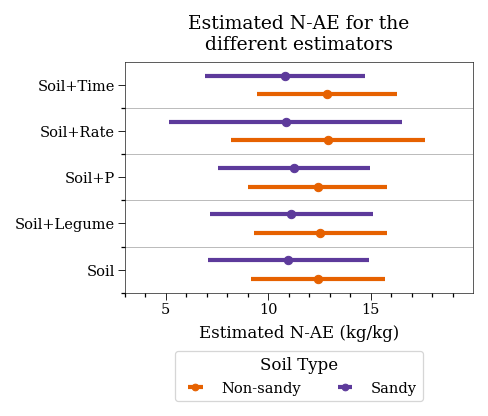

In [49]:
def plot_ate_groups(df, ax, count_col=None, mean_col="Mean", lowci_col="LowerCI", 
                    upci_col="UpperCI"):
    '''
    Makes a plot to compare the ATE estimates. The index must have two levels,
    being level_0 the group/model name, and level_1 the soil type. 
    '''
    for soil in ('Non-sandy', 'Sandy'):
        tmp_soil_df = df.loc[(slice(None), soil), :].reset_index(level=1)
        y = np.arange(len(tmp_soil_df)) - (0.2 if soil == 'Non-sandy' else -0.2)
        ax.errorbar(
            y=y,
            x=tmp_soil_df[mean_col],
            xerr=np.abs(tmp_soil_df[[lowci_col, upci_col]].values.T - tmp_soil_df[mean_col].values),
            fmt='o', label=soil, linewidth=2, markersize=4
        )
        if count_col is not None:
            for n, cluster in enumerate(tmp_soil_df.index):
                ax.text(
                    tmp_soil_df.loc[cluster, upci_col], y[n], 
                    f' ({tmp_soil_df.loc[cluster, count_col]}) ',
                    ha='left', va='center', fontsize=7
                )
    ax.set_yticks(np.arange(len(tmp_soil_df)))
    ax.set_xlabel('ATE Estimate (kg/ha)')
    ax.set_yticklabels(tmp_soil_df.index)


fig, ax = plt.subplots(1, 1, figsize=(3, 2))
tmp_df = ate_df.loc[(slice(None), slice('Non-sandy', 'Sandy')), :]
# tmp_df['count'] = 3
plot_ate_groups(tmp_df, ax,)

ax.set_xlabel('Estimated N-AE (kg/kg)')
ax.set_ylim(-0.5, 4.5)
# ax.set_title('Sample N-AE from\nthe different estimators')
# ax.axvline(cf_estimator.ate(X) * maize_std/100, color='k', linestyle='--', label='ATE')
ax.legend(title='Soil Type',loc='upper left', facecolor='none')
ax.set_title('Estimated N-AE for the\ndifferent estimators')
y = ax.get_yticks()
ax.set_yticks(y)
ax.set_yticks(y-.5, minor=True)
ax.grid(which='minor', axis='y', linestyle='-')
ax.grid(which='major', axis='y', linewidth=0)
ax.set_xticks(np.arange(0, 20, 1), minor=True)
ax.set_xticks(np.arange(0, 20, 5), minor=False)
ax.set_xlim(3, 20)
ax.legend(
    loc='lower center', bbox_to_anchor=(0.5, -.5, 0., .0), ncol=2, 
    title='Soil Type'
)

In [50]:
cluster_count_soil = cluster_count_soil.reset_index()
cluster_count_soil['soil_sandy'] = np.where(
    cluster_count_soil.soil_sandy > 0, 'Sandy', "Non-sandy"
)
cluster_count_soil = cluster_count_soil.set_index(['Cluster name', 'soil_sandy'])

CATE Intercept Results:  No intercept was fitted!


point_estimate  stderr  zstat  pvalue  ci_lower  \
Basal-Only   Non-sandy           6.465   8.330  0.776   0.438    -9.862   
             Sandy               9.807  17.930  0.547   0.584   -25.336   
Top-Only     Non-sandy          13.299   2.303  5.775   0.000     8.785   
             Sandy               8.400   2.336  3.596   0.000     3.821   
Basal+Single Non-sandy          15.233   3.587  4.247   0.000     8.203   
             Sandy              12.422   4.394  2.827   0.005     3.810   
Basal+Split  Non-sandy           8.163   3.217  2.537   0.011     1.858   
             Sandy              17.106   5.369  3.186   0.001     6.582   

                        ci_upper  count  
Basal-Only   Non-sandy    22.792     12  
             Sandy        44.949     17  
Top-Only     Non-sandy    17.813    402  
             Sandy        12.979    385  
Basal+Single Non-sandy    22.262    325  
             Sandy        21.035    196  
Basal+Split  Non-sandy    14.468    181  
             Sandy        27.630    103

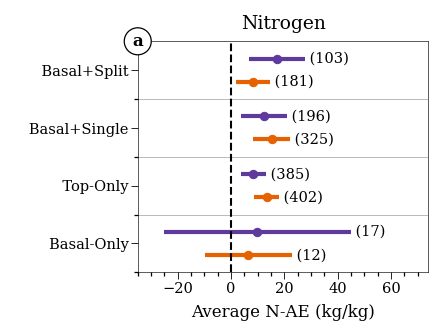

In [51]:
def get_coefs_df_from_summary(est, feature_names):
    coefs_df = pd.read_html(
        est.summary(feature_names=feature_names).tables[0].as_html()
        , header=0, index_col=0
    )[0]
    coefs_df.index = coefs_df.index.map(
        lambda x: tuple(x.split('_')[::-1])
    )
    return coefs_df

timing_coefs = get_coefs_df_from_summary(lineardml_soil_time, x_names_time)
cluster_order = [
    'Basal-Only', 'Top-Only', 'Basal+Single', 'Basal+Split'
]

timing_coefs = timing_coefs.loc[cluster_order, :]
tmp_df = timing_coefs.copy() # Convert to N-AE
tmp_df['count'] = cluster_count_soil.loc[timing_coefs.index]

# fig, ax = plt.subplots(1, 1, figsize=(2.5, 3.5))
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.))
plot_ate_groups(
    tmp_df, ax, count_col='count', mean_col='point_estimate', 
    lowci_col='ci_lower', upci_col='ci_upper'
)
ax.text(
    0, 1, 'a', transform=ax.transAxes, va='center', ha='center', fontsize=8,
    fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
)
ax.set_title('Nitrogen')
ax.set_xlabel('Average N-AE (kg/kg)')
ax.set_xlim(-24, 74)
ax.set_ylim(-.5, 3.5)
ax.axvline(0, color='k', linestyle='--')
y = ax.get_yticks()
ax.set_yticks(y)
ax.set_yticks(y-.5, minor=True)
ax.grid(which='minor', axis='y', linestyle='-')
ax.grid(which='major', axis='y', linewidth=0)
ax.set_xticks(np.arange(-35, 74, 5), minor=True)
ax.set_yticklabels([f'{i:>15}' for i in cluster_order])
# ax.legend(
#     loc='lower center', bbox_to_anchor=(0.5, -.5, 0., .0), ncol=2, 
#     title='Soil Type'
# )
# ax.set_title("Effect of N-fertilizer for\ndifferent application strategies")

fig.savefig(f'{DATA_PATH}/results/figures/N-fertilizer-timing-effects.pdf', bbox_inches='tight', dpi=300)
tmp_df

CATE Intercept Results:  No intercept was fitted!


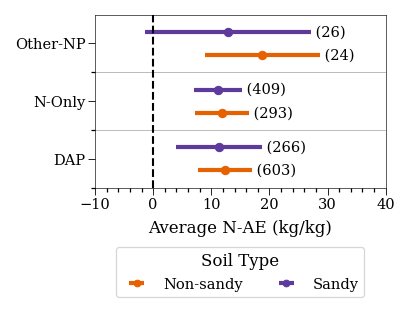

In [52]:
pfertilizer_coefs = get_coefs_df_from_summary(lineardml_soil_pfertilizer, x_names_pfertilizer)
pfertilizer_coefs['count'] =  X_soil_pfertilizer.sum(axis=0).astype(int)
tmp_df = pfertilizer_coefs.copy() 

fig, ax = plt.subplots(1, 1, figsize=(2.5, 1.5))
plot_ate_groups(
    tmp_df, ax, count_col='count', mean_col='point_estimate', 
    lowci_col='ci_lower', upci_col='ci_upper'
)

ax.set_xlabel('Average N-AE (kg/kg)')
ax.axvline(0, color='k', linestyle='--')
y = ax.get_yticks()
ax.set_yticks(y)
ax.set_yticks(y-.5, minor=True)
ax.set_ylim(-.5, 2.5)
ax.grid(which='minor', axis='y', linestyle='-')
ax.grid(which='major', axis='y', linewidth=0)
ax.set_xticks(np.arange(-10, 100, 2), minor=True)
ax.set_xlim(-10, 40)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -.3, 0., .0), ncol=2, title='Soil Type')
# ax.set_title("Effect of N-fertilizer for\ndifferent P-fertilizer groups")
fig.savefig(f'{DATA_PATH}/results/figures/N-fertilizer-pfert-effects.pdf', bbox_inches='tight', dpi=300)


CATE Intercept Results:  No intercept was fitted!


,,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper,count
Legume,Non-sandy,35.070,7.112,4.931,0.000,21.131,49.009,15
Non-legume,Non-sandy,12.170,1.681,7.239,0.000,8.875,15.465,905
Legume,Sandy,8.137,5.557,1.464,0.143,-2.755,19.029,36
Non-legume,Sandy,11.298,2.112,5.349,0.000,7.159,15.438,665


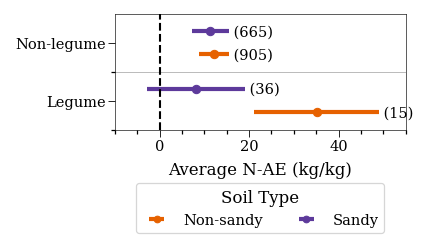

In [53]:
legume_coefs = get_coefs_df_from_summary(lineardml_soil_legume, x_names_legume)

legume_coefs['count'] =  X_soil_legume.sum(axis=0).astype(int)
tmp_df = legume_coefs.copy()
fig, ax = plt.subplots(1, 1, figsize=(2.5, 1.))
plot_ate_groups(
    legume_coefs, ax, count_col='count', mean_col='point_estimate', 
    lowci_col='ci_lower', upci_col='ci_upper'
)

ax.set_xlabel('Average N-AE (kg/kg)')
ax.axvline(0, color='k', linestyle='--')
y = ax.get_yticks()
ax.set_yticks(y)
ax.set_yticks(y-.5, minor=True)
ax.set_ylim(-.5, 1.5)
ax.grid(which='minor', axis='y', linestyle='-')
ax.grid(which='major', axis='y', linewidth=0)
ax.set_xticks(np.arange(-10, 100, 5), minor=True)
ax.set_xlim(-10, 55)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -.4, 0., .0), ncol=2, title='Soil Type')
# ax.set_title("Effect of N-fertilizer for\ndifferent Legume groups")
fig.savefig(f'{DATA_PATH}/results/figures/N-fertilizer-legume-effects.pdf', bbox_inches='tight', dpi=300)
legume_coefs

## Non-spatial variance

In [54]:
T_absolute = data.loc[transformed_data_pstrimmed.index, treatment_name].to_numpy()
Y_absolute = data.loc[transformed_data_pstrimmed.index, outcome_name].to_numpy()

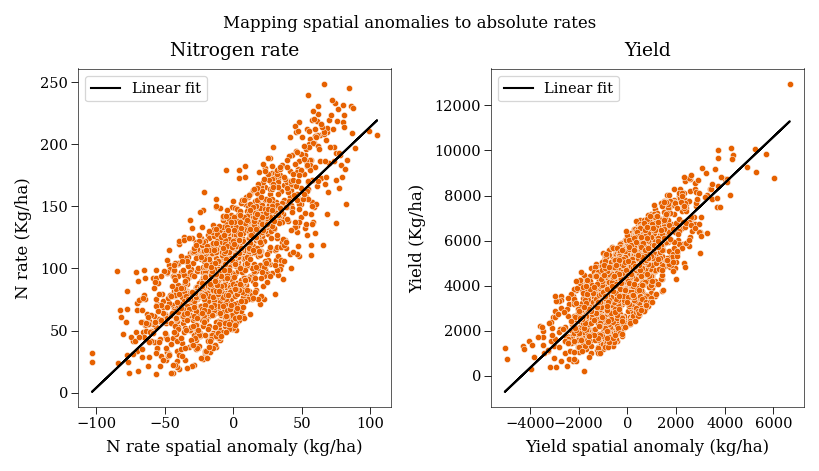

In [55]:
from statsmodels.api import OLS, add_constant

# A model to map spaital anomalies to absolute rates
fertilizer_anomaly_to_absolute = OLS(
    endog=T_absolute,
    exog=add_constant(T)
).fit()

yield_anomaly_to_absolute = OLS(
    endog=Y_absolute,
    exog=add_constant(Y)
).fit()

fig, axes = plt.subplots(1, 2, figsize=(5.5, 3))

ax = axes[0]
sns.scatterplot(x=T, y=T_absolute, ax=ax)
ax.set_xlabel('N rate spatial anomaly (kg/ha)')
ax.set_ylabel('N rate (Kg/ha)')
ax.plot(
    T, fertilizer_anomaly_to_absolute.predict(add_constant(T)), 
    color='k', linestyle='-', label='Linear fit'
)
plt.tight_layout()
ax.set_title('Nitrogen rate')
ax.legend()

ax = axes[1]
sns.scatterplot(x=Y, y=Y_absolute, ax=ax)
ax.set_xlabel('Yield spatial anomaly (kg/ha)')
ax.set_ylabel('Yield (Kg/ha)')
ax.plot(
    Y, yield_anomaly_to_absolute.predict(add_constant(Y)), 
    color='k', linestyle='-', label='Linear fit'
)
plt.tight_layout()
ax.set_title('Yield')
ax.legend()

fig.suptitle('Mapping spatial anomalies to absolute rates', y=1.02)

fertilizer_anomaly_to_absolute.rsquared, yield_anomaly_to_absolute.rsquared

Around 60% of the yield and nitrogen rates is not explained by spatial patterns. 

## Variable rate response

In [56]:
t_grid = np.linspace(np.percentile(T, 2.5), np.percentile(T, 97.5), 100)
t_absolute_grid = fertilizer_anomaly_to_absolute.predict(add_constant(t_grid))

def plot_response_curve(est, ax, X=None, ci=True, kwargs_line={}, kwargs_ci={},
                        t_grid=None):
    lift_inference = []
    if t_grid is None: 
        t_grid = np.linspace(np.percentile(T, 2.5), np.percentile(T, 97.5), 100)
    if isinstance(est, LinearDML):
        for t in t_grid: 
            if ci:
                ate_inf = est.ate_inference(X=X, T0=T0, T1=t)
                lift_inference.append((ate_inf.mean_point, *ate_inf.conf_int_mean()))
            else:
                lift_inference.append([est.ate(X=X, T0=0, T1=t)])
    elif est.shape[0] == 3:
        lift_inference = est.T
    else:
        lift_inference = est.reshape(-1, 1)      
    lift_inference = np.array(lift_inference)
    
    t_grid_ = t_grid 
    lift_inference_ = lift_inference

    sns.lineplot(
        x=t_grid_, y=lift_inference_[:, 0], ax=ax,
        **kwargs_line
    )
    if ci:
        if not kwargs_ci:
            kwargs_ci=dict(alpha=.1)
        ax.fill_between(
            x=t_grid_, y1=lift_inference_[:,1], 
            y2=lift_inference_[:,2], **kwargs_ci
        )
    ax.set_xlabel('N-Fertilizer rate (kg/ha)')
    ax.set_ylabel('Yield (kg/ha)')

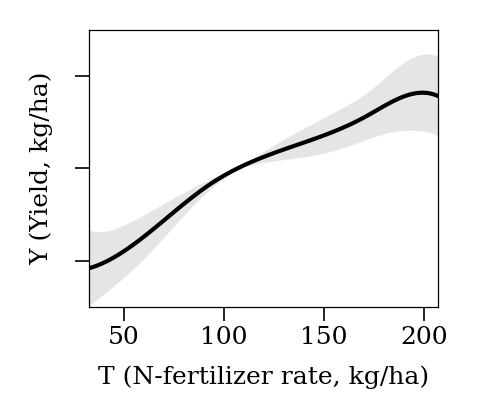

In [57]:
t_grid = np.linspace(np.percentile(T_absolute, 2.5), np.percentile(T_absolute, 97.5), 100)
lift_inference_rate = {
    'All': np.zeros(shape=(3, len(t_grid))),
    'Non-sandy': np.zeros(shape=(3, len(t_grid))),
    'Sandy': np.zeros(shape=(3, len(t_grid)))
}
for n, t in enumerate(t_grid): 
    ate_inf = rate_inference(X_soil, T0=T0, T1=t, y_offset=spatial_y)
    lift_inference_rate['All'][:, n] = (ate_inf['mean_point'], ate_inf['ci_mean_lower'], ate_inf['ci_mean_upper'])
    ate_inf = rate_inference(X_soil[X_soil[:, 1]==0], T0=T0, T1=t, y_offset=spatial_y)
    lift_inference_rate['Non-sandy'][:, n] = (ate_inf['mean_point'], ate_inf['ci_mean_lower'], ate_inf['ci_mean_upper'])
    ate_inf = rate_inference(X_soil[X_soil[:, 1]==1], T0=T0, T1=t, y_offset=spatial_y)
    lift_inference_rate['Sandy'][:, n] = (ate_inf['mean_point'], ate_inf['ci_mean_lower'], ate_inf['ci_mean_upper'])
    

fig, ax = plt.subplots(1, 1, figsize=(1.5, 1.2), dpi=300)
plot_response_curve(
    lift_inference_rate['All'], ax, t_grid=t_grid,
    kwargs_line=dict(color='k'), kwargs_ci=dict(color='k', alpha=.1, linewidth=0)
)
ax.set_yticklabels([])
ax.set_ylim(-1500, 1500)
ax.set_ylabel('Y (Yield, kg/ha)', fontsize=6)
ax.set_xlabel('T (N-fertilizer rate, kg/ha)', fontsize=6)
ax.set_xticks(np.arange(0, t_grid.max(), 50))
ax.set_xlim(t_grid.min(), t_grid.max())
ax.set_xticklabels(ax.get_xticklabels(), fontsize=6)
fig.savefig(f'{DATA_PATH}/results/figures/all-N-fertilizer-dose-response.svg', bbox_inches='tight', dpi=300, transparent=True)
# fig.savefig(f'{DATA_PATH}/results/figures/poster/all-N-fertilizer-dose-response.png', bbox_inches='tight', dpi=1200)

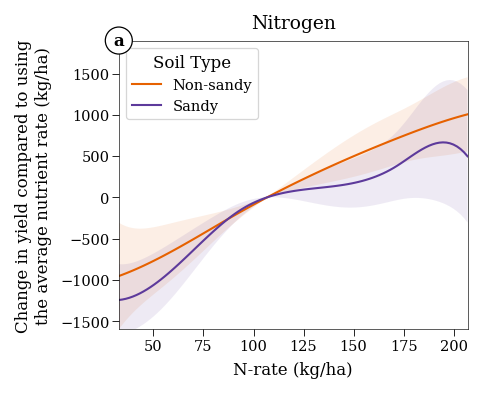

In [58]:
fig, ax =plt.subplots(1, 1, figsize=(3, 2.5))
plot_response_curve(
    lift_inference_rate['Non-sandy'], ax, X=X_soil[X_soil[:,0].astype(bool)],
    kwargs_line=dict(label='Non-sandy'), t_grid=t_grid
)
plot_response_curve(
    lift_inference_rate['Sandy'], ax, X=X_soil[X_soil[:,1].astype(bool)],
    kwargs_line=dict(label='Sandy'), t_grid=t_grid
)

ax.set_title('Average N-fertilizer response')

ax.set_xlabel('N-rate (kg/ha)')
ax.set_title('Nitrogen')
ax.legend(loc='upper left', title='Soil Type')
ax.text(
    0, 1, 'a', transform=ax.transAxes, va='center', ha='center', fontsize=8,
    fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k'), zorder=6
)
# ax.set_yticks(np.arange(-1600, 2500, 500))
# ax.set_yticks(np.arange(-1600, 2500, 100), minor=True)
ax.grid(which='minor', linestyle=':')
ax.set_ylabel('Change in yield compared to using\nthe average nutrient rate (kg/ha)')
ax.set_ylim(-1600, 1900)
ax.set_xlim(t_grid.min(), t_grid.max())

# ax.set_xlim(0, 100*T.max())
fig.savefig(f'{DATA_PATH}/results/figures/N-fertilizer-dose-response-curve.pdf', bbox_inches='tight', dpi=300)
# fig.savefig(f'{DATA_PATH}/results/figures/poster/N-fertilizer-dose-response-curve.png', bbox_inches='tight', dpi=1200)

In [59]:
# The spatial average of the treatment
spatial_t_mean_sand = pd.DataFrame([
    spatial_t, X_soil[:, 1] 
]).T.groupby(1).mean().iloc[:, 0]
spatial_t_mean_sand.index = ['Non-sandy', 'Sandy']
spatial_t_mean_sand.name = 'N spatial mean'
spatial_t_mean_sand

Non-sandy    109.345026
Sandy        109.728018
Name: N spatial mean, dtype: float64

In [60]:
t25, t75

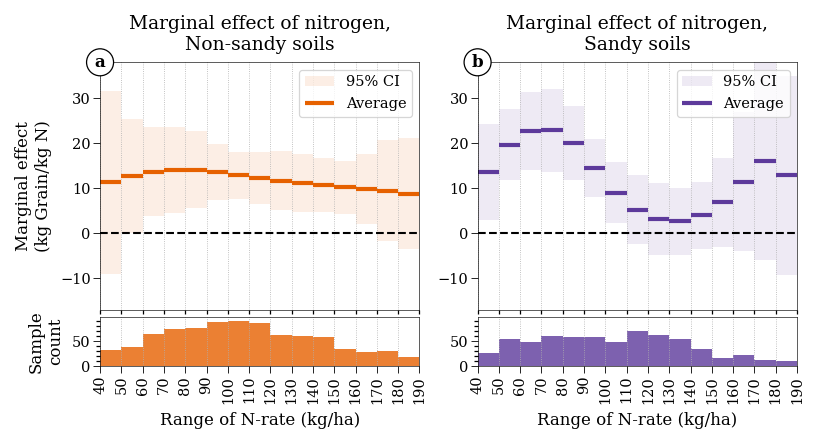

In [61]:
# Marginal response for amount ranges
cycle_colors = [i['color'] for i in plt.rcParams['axes.prop_cycle']]
step_size = 10
fig, axes = plt.subplots(2, 2, figsize=(5.5, 3), sharey=False, sharex=False, height_ratios=[5, 1])

x_ = np.arange(0, 200, step_size)
x = np.arange(40, 200, step_size)
x_ = x 
lift_amount_df = pd.DataFrame(
    columns=pd.MultiIndex.from_tuples([
        ('Non-sandy', 'Mean'), ('Non-sandy', 'LowerCI'), ('Non-sandy', 'UpperCI'),
        ('Sandy', 'Mean'), ('Sandy', 'LowerCI'), ('Sandy', 'UpperCI')
    ]), index=x_[:-1]
)
for n, soil in enumerate(('Non-sandy', 'Sandy')):
    ax = axes[0][n]
    ax2 = axes[1][n]
    ax.axhline(0, color='k', linestyle='--')
    lift_inference = []
    for i, t in enumerate(x[:-1]):
        t1 = x[i+1]
        ate_inf = rate_inference(X=X_soil[X_soil[:, n].astype(bool)],  T0=t, T1=t1)
        lift_inference.append(
            np.array([ate_inf['mean_point'], ate_inf['ci_mean_lower'], ate_inf['ci_mean_upper']])/(t1 - t)
        )
        lift_amount_df.loc[t, (soil, slice(None))] = lift_inference[-1]
        T_ = T_absolute[X_soil[:, n].astype(bool)]
        # ax.text(
        #     x_[i] + (x_[i+1] - x_[i])/2, lift_inference[-1][2]+1, f'({((T_ >= t) & (T_ < t1)).sum()})', 
        #     ha='center', fontsize=7
        # )
        ax.fill_between(
            x=[x_[i], x_[i+1]], y1=lift_inference[-1][1], y2=lift_inference[-1][2],
            alpha=0.1, color=cycle_colors[n], linewidth=0, label='95% CI' if i==0 else None
        )

        ax2.fill_between(
            x=[x_[i], x_[i+1]], y1=0, y2=((T_ >= t) & (T_ < t1)).sum(),
            alpha=.8, color=cycle_colors[n], linewidth=0, label='95% CI' if i==0 else None
        )
    lift_inference = np.array(lift_inference)
    err = np.abs(lift_inference[:, 1:] - lift_inference[:, 0].reshape(-1, 1)).T 
    ax.hlines(
        y=lift_inference[:, 0], xmin=x_[:-1], xmax=x_[1:], linewidth=2,
        label='Average', color=cycle_colors[n]
    )
    if n == 0: ax.set_ylabel('Marginal effect\n(kg Grain/kg N)')
    ax.set_xticks(x_[:])
    # ax.set_yticks(np.arange(-50, 100, 2), minor=True)
    ax.grid(which='major', linestyle=':', axis='x')
    # ax.grid(which='minor', linestyle='-')
    ax.set_ylim(-17, 38)
    ax.set_xlim(x_[0], x_[-1])
    ax.set_title(f'Marginal effect of nitrogen,\n{soil} soils')
    ax.text(
        0, 1, ('a', 'b')[n], transform=ax.transAxes, va='center', ha='center', fontsize=8,
        fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
    )
    ax.set_xticks(ax.get_xticks(), minor=True)
    ax.set_xticks([], minor=False)
    ax.grid(which='minor', linestyle=':', axis='x')
    # ax.set_xticks([-900, 900], minor=False)
    ax.legend(loc='upper right')
    # Histplot
    ax2.set_ylim(0, 99)
    ax2.set_xticks(x_[:])
    ax2.set_xlim(x_[0], x_[-1])
    ax2.set_yticks(np.arange(0, 100, 10), minor=True)
    ax2.grid(which='major', linestyle=':', axis='x')
    # ax2.grid(which='minor', linestyle='-')
    ax2.set_xticklabels([f'{x_[i]:.0f}' for i, _ in enumerate(x_[:])], rotation=90)
    ax2.set_xlabel('Range of N-rate (kg/ha)')
    # ax2.yaxis.tick_right()
    # ax2.yaxis.set_label_position("right")
    if n == 0: ax2.set_ylabel('Sample\ncount',)
plt.tight_layout()
plt.subplots_adjust(hspace=.05)


# fig.suptitle(f'Average marginal effect of N Fertilizer for\ngiven  {step_size} kg/ha N fertilizer ranges', y=1.05)
fig.savefig(f'{DATA_PATH}/results/figures/N-fertilizer-marginal-dose-response.pdf', bbox_inches='tight', dpi=300)
lift_amount_df['Fertilizer rate'] = lift_amount_df.index + T_absolute.mean()
lift_amount_df.style.format(precision=1)

# Benchmark models

The benchmark models are used to compare our approach. Two benchmarks will be used: regular causal Linear OLS, and Predictive ML

## Causal OLS

In [62]:
from statsmodels.api import OLS

In [63]:
# OLS model for homogeneous effect
ols_data = transformed_data_pstrimmed[dml_soil_features].copy()
ols_data[outcome_name] = demeaned_outcome
ols_data[treatment_name] = demeaned_treatment
ols_data = ols_data.join([
    (ols_data[treatment_name] * 
        (ols_data['soil_sandy'].astype(bool))).rename('N_sandy'),
    (ols_data[treatment_name] * 
        (~ols_data['soil_sandy'].astype(bool))).rename('N_nosandy')
])
ols_data = ols_data.drop(columns=treatment_name)
ols_model_hom = OLS(
    endog=ols_data[outcome_name],
    exog=ols_data.drop(columns=[outcome_name])
).fit().summary()
pd.read_html(
    ols_model_hom.tables[1].as_html()
    , header=0, index_col=0
)[0].loc[['N_sandy', 'N_nosandy']]

,coef,std err,t,P>|t|,[0.025,0.975]
N_sandy,10.1869,1.661,6.133,0.0,6.929,13.445
N_nosandy,10.6845,1.292,8.268,0.0,8.150,13.219


## Predictive ML

In [64]:
from sklearn.base import clone
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
# A RF with PDP to simulate the effect of fertilizer on yield
# This article was just released and it uses PDP: https://www.sciencedirect.com/science/article/pii/S1161030125004216
# X_rf_response = np.hstack([W, T.reshape(-1, 1)])

data_ml_pred = data.copy() # This uses all data, so the effect identification phase is skipped
data_ml_pred = data_ml_pred.drop(columns=['crop_name', 'crop_maize', 'outcome_prodstd'])
data_ml_pred = data_ml_pred.loc[transformed_data_pstrimmed.index]
# data_ml_pred[treatment_name] = demeaned_treatment + spatial_t
# data_ml_pred[outcome_name] = demeaned_outcome + spatial_y
X_rf_response = data_ml_pred.drop(columns=[outcome_name])
Y_rf_response = data_ml_pred[outcome_name]
model_rf_response = clone(model_q)
y_cv_pred = cross_val_predict(
    model_rf_response,
    X_rf_response,
    Y_rf_response,
)
model_rf_response = model_rf_response.fit(X_rf_response, Y_rf_response)
r2_score(Y_rf_response, y_cv_pred)

In [65]:
pd.Series(
    model_rf_response.feature_importances_,
    index=X_rf_response.columns
).sort_values(ascending=False).head(10)

fertN_total               0.079930
fertP_total               0.057287
soilfert_cec              0.054850
variety_hybrid            0.040785
soilpp_sand               0.033854
variety_recycled          0.033355
soilpp_clay               0.027493
20to30perc_season_prec    0.026048
0to10perc_season_tmean    0.025914
soilpp_density            0.024945
dtype: float64

In [66]:
X_rf_response_t0 = X_rf_response.copy()
X_rf_response_t1 = X_rf_response.copy()

X_rf_response_t0[treatment_name] = t25
X_rf_response_t1[treatment_name] = t75

model_rf_ite = (
    model_rf_response.predict(X_rf_response_t1) - model_rf_response.predict(X_rf_response_t0)
)/X_rf_response_t1[treatment_name]
model_rf_ite = model_rf_ite.to_frame()
model_rf_ite.describe()

,fertN_total
count,1621.000000
mean,2.641187
std,1.286576
min,-1.281949
25%,1.703044
50%,2.616565
75%,3.521296
max,6.965004


In [67]:
rf_response_pdp = partial_dependence(
    model_rf_response, X_rf_response, features=[treatment_name],
    kind='individual'
)

model_rf_response.predict(X_rf_response)

array([2608.32654654, 3061.18705112, 3919.26255093, ..., 5395.32629209,
       5066.97366081, 4505.45058932], shape=(1621,))

In [68]:
rf_response_df_sandy = {}
rf_response_df_nonsandy = {}
rf_response_df = {}
X_rf_response_t0 = X_rf_response.copy()
X_rf_response_t0[treatment_name] = T_absolute.mean()
for t in t_grid:
    X_rf_response_t1 = X_rf_response.copy()
    X_rf_response_t1[treatment_name] = t
    rf_response_df[t] = model_rf_response.predict(X_rf_response_t1) - model_rf_response.predict(X_rf_response_t0)
    rf_response_df_sandy[t] = model_rf_response.predict(X_rf_response_t1.loc[X_rf_response_t1['soil_sandy']]) - \
        model_rf_response.predict(X_rf_response_t0.loc[X_rf_response_t0['soil_sandy']])
    rf_response_df_nonsandy[t] = model_rf_response.predict(X_rf_response_t1.loc[~X_rf_response_t1['soil_sandy']]) - \
        model_rf_response.predict(X_rf_response_t0.loc[~X_rf_response_t0['soil_sandy']])
rf_response_df_sandy = pd.DataFrame(rf_response_df_sandy)
rf_response_df_sandy = pd.melt(rf_response_df_sandy)
rf_response_df_nonsandy = pd.DataFrame(rf_response_df_nonsandy)
rf_response_df_nonsandy = pd.melt(rf_response_df_nonsandy)
rf_response_df = pd.DataFrame(rf_response_df)
rf_response_df = pd.melt(rf_response_df)

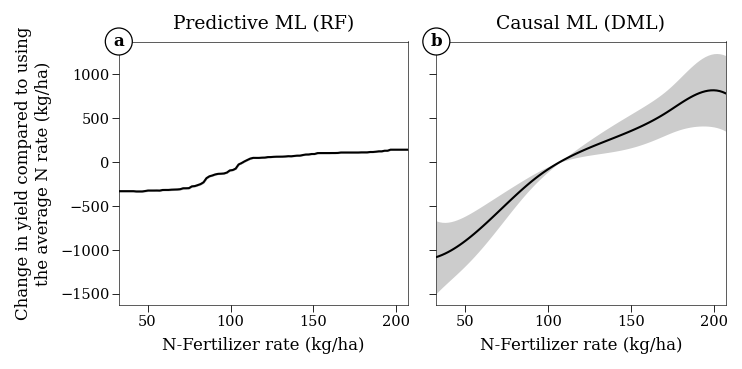

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(5, 2.5), sharex=True, sharey=True)
ax = axes[0]
sns.lineplot(
    rf_response_df,
    x='variable',
    y='value',
    errorbar='se', ax=ax,
    color='k'
)
ax.set_xlabel('N-Fertilizer rate (kg/ha)')
ax.set_ylabel('Change in yield compared to using\nthe average N rate (kg/ha)')
ax.set_title('Predictive ML (RF)')
ax.set_xlim(t_grid.min(), t_grid.max())

ax = axes[1]
plot_response_curve(
    lift_inference_rate['All'], ax, kwargs_ci=dict(alpha=.2, color='k', linewidth=0), 
    t_grid=t_grid, kwargs_line=dict(color='k')
)
ax.set_title('Causal ML (DML)')
ax.set_xlabel('N-Fertilizer rate (kg/ha)')
ax.set_xlim(t_grid.min(), t_grid.max())

for n, ax in enumerate(axes):
    ax.text(
        0, 1, ('a', 'b')[n], transform=ax.transAxes, va='center', ha='center', fontsize=8,
        fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
    )

# ax.set_xlim(0, 100*T.max())
fig.savefig(f'{DATA_PATH}/results/figures/N-fertilizer-predictive-vs-causal.pdf', bbox_inches='tight', dpi=300)
plt.tight_layout()

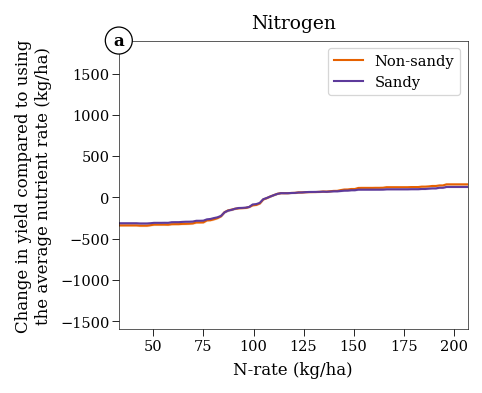

In [70]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2.5), sharex=True, sharey=True)
sns.lineplot(
    rf_response_df_nonsandy,
    x='variable',
    y='value',
    errorbar='se', ax=ax,
    color=cycle_colors[0], label='Non-sandy'
)
sns.lineplot(
    rf_response_df_sandy,
    x='variable',
    y='value',
    errorbar='se', ax=ax,
    color=cycle_colors[1], label='Sandy'
)
ax.set_xlabel('N-rate (kg/ha)')
ax.set_title('Nitrogen')
ax.set_xlim(t_grid.min(), t_grid.max())
ax.set_ylim(-1600, 1900)
ax.text(
    0, 1, ('a', 'b')[0], transform=ax.transAxes, va='center', ha='center', fontsize=8,
    fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
)
ax.set_ylabel('Change in yield compared to using\nthe average nutrient rate (kg/ha)')
# ax.set_xlim(0, 100*T.max())
fig.savefig(f'{DATA_PATH}/results/figures/N-fertilizer-predictive.pdf', bbox_inches='tight', dpi=300)
fig.savefig(f'{DATA_PATH}/results/figures/poster/N-fertilizer-predictive.png', bbox_inches='tight', dpi=1200)

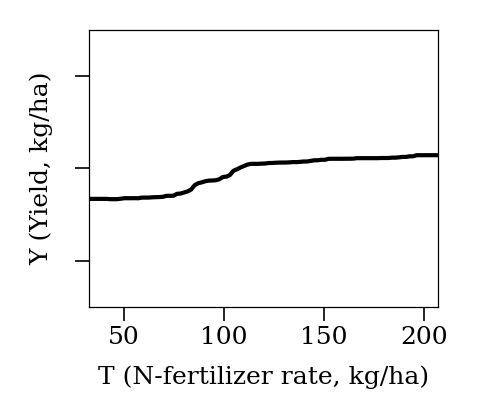

In [71]:
fig, ax = plt.subplots(1, 1, figsize=(1.5, 1.2), dpi=300)
sns.lineplot(
    rf_response_df,
    x='variable',
    y='value',
    errorbar='se', ax=ax,
    color='k'
)
ax.set_ylim(-1500, 1500)

ax.set_yticklabels([])
ax.set_ylabel('Y (Yield, kg/ha)', fontsize=6)
ax.set_xlabel('T (N-fertilizer rate, kg/ha)', fontsize=6)
ax.set_xticks(np.arange(0, t_grid.max(), 50))
ax.set_xlim(t_grid.min(), t_grid.max())
ax.set_xticklabels(ax.get_xticklabels(), fontsize=6)
fig.savefig(f'{DATA_PATH}/results/figures/all-N-fertilizer-dose-response-predictive.svg', bbox_inches='tight', dpi=300, transparent=True)
fig.savefig(f'{DATA_PATH}/results/figures/poster/all-N-fertilizer-dose-response-predictive.png', bbox_inches='tight', dpi=1500)

# Robustness checks

## Sensitivity analysis

In [72]:
lineardml_only_soil.sensitivity_summary()

<class 'econml.utilities.Summary'>
"""
Sensitivity Analysis Summary for c_y=0.05, c_t=0.05, rho=1.0
================================================
CI Lower Theta Lower Theta  Theta Upper CI Upper
------------------------------------------------
   6.884       9.398 11.852      14.306   16.825
   Robustness Values for null_hypothesis=0    
==============================================
Robustness Value (Theta) Robustness Value (CI)
----------------------------------------------
                   0.219                 0.176
----------------------------------------------
"""

In [73]:
lineardml_soil_time.sensitivity_summary()

<class 'econml.utilities.Summary'>
"""
Sensitivity Analysis Summary for c_y=0.05, c_t=0.05, rho=1.0
================================================
CI Lower Theta Lower Theta  Theta Upper CI Upper
------------------------------------------------
   7.041       9.559 12.011      14.462   16.989
   Robustness Values for null_hypothesis=0    
==============================================
Robustness Value (Theta) Robustness Value (CI)
----------------------------------------------
                   0.222                 0.179
----------------------------------------------
"""

In [74]:
lineardml_soil_pfertilizer.sensitivity_summary()

<class 'econml.utilities.Summary'>
"""
Sensitivity Analysis Summary for c_y=0.05, c_t=0.05, rho=1.0
================================================
CI Lower Theta Lower Theta  Theta Upper CI Upper
------------------------------------------------
   7.032       9.534 11.969      14.404   16.914
   Robustness Values for null_hypothesis=0    
==============================================
Robustness Value (Theta) Robustness Value (CI)
----------------------------------------------
                   0.222                  0.18
----------------------------------------------
"""

In [75]:
lineardml_soil_legume.sensitivity_summary()

<class 'econml.utilities.Summary'>
"""
Sensitivity Analysis Summary for c_y=0.05, c_t=0.05, rho=1.0
================================================
CI Lower Theta Lower Theta  Theta Upper CI Upper
------------------------------------------------
    6.98       9.508 11.977      14.445   16.981
   Robustness Values for null_hypothesis=0    
==============================================
Robustness Value (Theta) Robustness Value (CI)
----------------------------------------------
                    0.22                 0.177
----------------------------------------------
"""

## Placebo test

In [76]:
from tqdm import tqdm

In [77]:
# Run placebo for the Timing and Amount heterogeneous estimators
placebo_coefs_estimates_dict = {
    'Soil': [],
    'Soil+Rate': [],
    'Soil+Time': [],
    'Soil+P': [],
    'Soil+Legume': [] 
}
# placebo_coefs_estimates_dict['Amount rate'] = []
placebo_rate_response = []

N_PLACEBO_RUNS = 0
if N_PLACEBO_RUNS < 1:
    with open(f'{DATA_PATH}/results/robustness-checks/N-response-placebo', 'rb') as f:
        placebo_coefs_estimates_dict, placebo_rate_response = pickle.load(f)

# placebo_coefs_estimates_dict['Soil+Rate'] = []
# placebo_rate_response = []
# N_PLACEBO_RUNS = 100

for _ in tqdm(range(N_PLACEBO_RUNS)):
    T_placebo = np.random.choice(T_absolute, size=len(T_absolute), replace=True)
    # Heterogeneous by soil and amount
    lineardml_amount_placebo = LinearDML(
        model_y=model_q, 
        model_t=MultiOutputRegressor(model_treatment), 
        treatment_featurizer=treatment_featurizer,
        discrete_treatment=False,
        cv=5,
        random_state=RANDOM_SEED,
        fit_cate_intercept=False,
    )
    lineardml_amount_placebo = lineardml_amount_placebo.fit(
        Y=Y, T=T_placebo.reshape(-1, 1), W=W_soil, X=X_soil,
        inference='statsmodels', cache_values=True,
    )
    placebo_df = pd.DataFrame([
        list(rate_inference(
            X_soil[X_soil[:, 0] == 1], est=lineardml_amount_placebo, 
            T0=t25, T1=t75, y_offset=0, scale=(t75-t25)
        ).values()),
        list(rate_inference(
            X_soil[X_soil[:, 1] == 1], est=lineardml_amount_placebo,  
            T0=t25, T1=t75, y_offset=0, scale=(t75-t25)
        ).values())
    ], columns=['point_estimate', 'stderr', 'ci_lower', 'ci_upper', 'pvalue'], index=['Non-sandy', 'Sandy'])
    placebo_coefs_estimates_dict['Soil+Rate'].append(placebo_df)
    placebo_rate_response.append(
        np.array([
            lineardml_amount_placebo.ate(X_soil, T0=T0, T1=i) 
            for i in t_grid
        ])
    )

0it [00:00, ?it/s]


In [78]:
for _ in tqdm(range(N_PLACEBO_RUNS)):
    T_placebo = np.random.choice(T, size=len(T), replace=True)
    # Heterogeneous by Soil and time
    lineardml_time_placebo = LinearDML(
        model_y=model_q, 
        model_t=model_treatment, 
        discrete_treatment=False,
        cv=5,
        random_state=RANDOM_SEED,
        fit_cate_intercept=False,
    )
    lineardml_time_placebo = lineardml_time_placebo.fit(
        Y=Y, T=T_placebo, W=W_soil_time, X=X_soil_time,
        inference='statsmodels', cache_values=True,
    )
    placebo_coefs_estimates_dict['Soil+Time'].append(
        get_coefs_df_from_summary(lineardml_time_placebo, x_names_time)
    )

0it [00:00, ?it/s]


In [79]:
for _ in tqdm(range(N_PLACEBO_RUNS)):
    T_placebo = np.random.choice(T, size=len(T), replace=True)
    # Heterogeneous by Soil only
    lineardml_soil_placebo = LinearDML(
        model_y=model_q, 
        model_t=model_treatment, 
        discrete_treatment=False,
        cv=5,
        random_state=RANDOM_SEED,
        fit_cate_intercept=False,
    )
    lineardml_soil_placebo = lineardml_soil_placebo.fit(
        Y=Y, T=T_placebo, W=W_soil, X=X_soil,
        inference='statsmodels', cache_values=True,
    )
    placebo_coefs_estimates_dict['Soil'].append(
        get_coefs_df_from_summary(lineardml_soil_placebo, x_names_soil)
    )

0it [00:00, ?it/s]


In [80]:
for _ in tqdm(range(N_PLACEBO_RUNS)):
    T_placebo = np.random.choice(T, size=len(T), replace=True)
    # Heterogeneous by Soil and P-Fertilizer
    lineardml_pfertilizer_placebo = LinearDML(
        model_y=model_q, 
        model_t=model_treatment, 
        discrete_treatment=False,
        cv=5,
        random_state=RANDOM_SEED,
        fit_cate_intercept=False,
    )
    lineardml_pfertilizer_placebo = lineardml_pfertilizer_placebo.fit(
        Y=Y, T=T_placebo, W=W_soil_pfertilizer, X=X_soil_pfertilizer,
        inference='statsmodels', cache_values=True,
    )
    placebo_coefs_estimates_dict['Soil+P'].append(
        get_coefs_df_from_summary(lineardml_pfertilizer_placebo, x_names_pfertilizer)
    )

0it [00:00, ?it/s]


In [81]:
for _ in tqdm(range(N_PLACEBO_RUNS)):
    T_placebo = np.random.choice(T, size=len(T), replace=True)
    # Heterogeneous by Soil and Legume
    lineardml_legume_placebo = LinearDML(
        model_y=model_q, 
        model_t=model_treatment, 
        discrete_treatment=False,
        cv=5,
        random_state=RANDOM_SEED,
        fit_cate_intercept=False,
    )
    lineardml_legume_placebo = lineardml_legume_placebo.fit(
        Y=Y, T=T_placebo, W=W_soil_legume, X=X_soil_legume,
        inference='statsmodels', cache_values=True,
    )
    placebo_coefs_estimates_dict['Soil+Legume'].append(
        get_coefs_df_from_summary(lineardml_legume_placebo, x_names_legume)
    )

0it [00:00, ?it/s]


In [82]:
with open(f'{DATA_PATH}/results/robustness-checks/N-response-placebo', 'wb') as f:
    pickle.dump((placebo_coefs_estimates_dict, placebo_rate_response), f)

In [83]:
def get_placebo_results(list_df_coefs):
    tmp_df = pd.concat(list_df_coefs)
    levels = list(range(tmp_df.index.nlevels))
    point_estimate = tmp_df.groupby(level=levels).point_estimate.mean()
    stderr = tmp_df.groupby(level=levels).point_estimate.agg(lambda x: np.sqrt((x**2).mean()))
    pvalue = tmp_df.groupby(level=levels).point_estimate.agg(
        lambda x: 2*min((x >= 0).mean(), (x < 0).mean())
    )
    tmp_df = pd.concat([point_estimate.to_frame(), stderr.to_frame(), pvalue.to_frame()], axis=1)
    tmp_df.columns = ['point_estimate', 'stderr', 'pvalue'] 
    return tmp_df

placebo_results_df = []
for est, list_df_coefs in placebo_coefs_estimates_dict.items():
    tmp_df = get_placebo_results(list_df_coefs)
    tmp_df['est'] = est
    tmp_df = tmp_df.reset_index()
    if 'index' in tmp_df.columns:
        tmp_df = tmp_df.rename(columns={'index': 'level_1'})
    placebo_results_df.append(tmp_df)
placebo_results_df = pd.concat(placebo_results_df)
placebo_results_df = placebo_results_df.set_index(['est', 'level_0', 'level_1'])
placebo_results_df.index = placebo_results_df.index.reorder_levels([0, 2, 1])
placebo_results_df = placebo_results_df.sort_index()

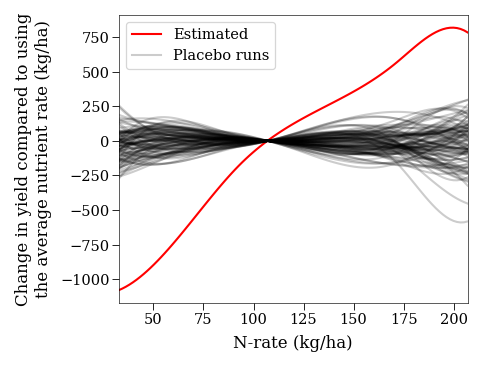

In [84]:
fig, ax =plt.subplots(1, 1, figsize=(3, 2.5))
plot_response_curve(
    lift_inference_rate['All'], ax, ci=False, 
    kwargs_line=dict(label='Estimated', color='r'), t_grid=t_grid
)

# placebo_t_grid = np.quantile(T, np.linspace(0.025, 0.975, 100))

for est in placebo_rate_response:
    plot_response_curve(
        est, ax, ci=False, kwargs_line=dict(color='k', alpha=.2),
        X=X_soil, t_grid=t_grid
    )
plot_response_curve(
    est, ax, ci=False, kwargs_line=dict(color='k', alpha=.2, label='Placebo runs'),
    X=X_soil, t_grid=t_grid
)

# ax.set_title('Average N-fertilizer response')
ax.set_xlim(t_grid.min(), t_grid.max())
ax.set_ylabel('Change in yield compared to using\nthe average nutrient rate (kg/ha)')
ax.set_xlabel('N-rate (kg/ha)')
# ax.set_xlim(0, 100*T.max())
ax.legend()
fig.savefig(f'{DATA_PATH}/results/figures/N-fertilizer-dose-response-curve-placebo.pdf', bbox_inches='tight', dpi=300)

# Analysis for publication

## Descriptive stats tables

In [85]:
columns_stats = []
for n in adjustment_nodes:
    if n not in ('weather', 'soil'):
        columns_stats += columns_dict[n] 

In [86]:
stats_survey = data.loc[index_zone_subset][
    columns_stats + ["outcome_prodkgha", treatment_name, 'soil_sandy'] + 
    [f'fert{"P" if "N" in treatment_name else "N"}_total'] +  # Extra variables used in Phosphorus analysis
    list(data.filter(like='variety').columns) + 
    columns_dict['otherManagement']
].astype(float).describe().T[['mean', 'std', 'min', 'max']]

cat_map = {i: k for k, v in columns_dict.items() for i in v}
cat_map['outcome_prodkgha'] = 'outcome'
stats_survey.index = pd.MultiIndex.from_tuples([
    (cat_map[i], i)
    for i in stats_survey.index
])
stats_survey['range'] = stats_survey.apply(lambda row: f"{row['min']:.3f} - {row['max']:.3f}", axis=1)
stats_survey = stats_survey.drop(columns=['min', 'max'])
stats_survey.sort_index().style.format({'mean': '{:.3f}', 'sd': '{:.3f}'})

In [87]:
print(stats_survey.style.format(precision=3).to_latex())

\begin{tabular}{llrrl}
 &  & mean & std & range \\
\multirow[c]{10}{*}{fertilizerTiming} & fertN_56leaves & 0.352 & 0.316 & 0.000 - 1.000 \\
 & fertN_810leaves & 0.404 & 0.308 & 0.000 - 1.000 \\
 & fertN_basal & 0.156 & 0.202 & 0.000 - 1.000 \\
 & fertN_kneehigh & 0.071 & 0.216 & 0.000 - 1.000 \\
 & fertN_tasselingsilking & 0.016 & 0.100 & 0.000 - 1.000 \\
 & fertP_56leaves & 0.102 & 0.297 & 0.000 - 1.000 \\
 & fertP_810leaves & 0.009 & 0.062 & 0.000 - 0.600 \\
 & fertP_basal & 0.447 & 0.493 & 0.000 - 1.000 \\
 & fertP_kneehigh & 0.000 & 0.012 & 0.000 - 0.333 \\
 & fertP_tasselingsilking & 0.000 & 0.000 & 0.000 - 0.000 \\
accessibilityRAI & accessibility_rai & 0.837 & 0.115 & 0.538 - 1.000 \\
investmentCap & investing_capacity_index & 0.334 & 0.146 & 0.083 - 0.833 \\
\multirow[c]{7}{*}{fieldHistory} & fieldsize_value & 0.611 & 0.529 & 0.043 - 4.076 \\
 & history_maize & 0.837 & 0.369 & 0.000 - 1.000 \\
 & history_nocrop & 0.030 & 0.171 & 0.000 - 1.000 \\
 & history_legume & 0.138 & 0.3

In [88]:
transformed_data_pstrimmed.shape

In [89]:
fert_timing_stats = data.loc[index_zone_subset].filter(like='fertN').describe().T[['mean', 'std', 'min', 'max']]
fert_timing_stats = pd.concat([
    fert_timing_stats, 
    data.loc[index_zone_subset].loc[data.fertP_total > 0].filter(like='fertP').describe().T[['mean', 'std', 'min', 'max']]
])
fert_timing_stats = fert_timing_stats.drop(['fertN_total', 'fertP_total'])
fert_timing_stats['range'] = fert_timing_stats.apply(lambda row: f"{row['min']:.3f} - {row['max']:.3f}", axis=1)
fert_timing_stats = fert_timing_stats.drop(columns=['min', 'max'])
fert_timing_stats.sort_index().style.format({'mean': '{:.3f}', 'sd': '{:.3f}'})

,mean,std,range
fertN_56leaves,0.352,0.315700,0.000 - 1.000
fertN_810leaves,0.404,0.308247,0.000 - 1.000
fertN_basal,0.156,0.201595,0.000 - 1.000
fertN_kneehigh,0.071,0.215773,0.000 - 1.000
fertN_tasselingsilking,0.016,0.099809,0.000 - 1.000
fertP_56leaves,0.183,0.377918,0.000 - 1.000
fertP_810leaves,0.016,0.082200,0.000 - 0.600
fertP_basal,0.800,0.389940,0.000 - 1.000
fertP_kneehigh,0.001,0.015661,0.000 - 0.333
fertP_tasselingsilking,0.000,0.000000,0.000 - 0.000


In [90]:
env_stats = data.loc[index_zone_subset].filter(like='0to100').describe().drop(columns=data.filter(like='90to').columns).T[['mean', 'std', 'min', 'max']]
env_stats = pd.concat([
    env_stats,
    data.loc[index_zone_subset].filter(like='soil').drop(columns=['soil_sandy', 'residue_incorporateinthesoil']).describe().T[['mean', 'std', 'min', 'max']]
])
env_stats['range'] = env_stats.apply(lambda row: f"{row['min']:.3f} - {row['max']:.3f}", axis=1)
env_stats = env_stats.drop(columns=['min', 'max'])
env_stats.sort_index().style.format({'mean': '{:.3f}', 'sd': '{:.3f}'})

,mean,std,range
0to100perc_season_prec,6.811,1.121825,0.845 - 10.482
0to100perc_season_rainydays,0.591,0.078262,0.160 - 0.798
0to100perc_season_srad,17.628,0.631756,16.146 - 19.440
0to100perc_season_tmean,20.163,0.996775,15.819 - 23.713
soilfert_cec,25.296,1.387215,20.000 - 29.667
soilfert_oc,23.657,1.786125,18.778 - 29.556
soilpp_clay,29.274,4.291930,18.333 - 39.667
soilpp_density,133.243,4.410706,109.667 - 146.667
soilpp_sand,53.433,5.282676,41.000 - 72.222


In [91]:
print(stats_survey.sort_index().style.format({'mean': '{:.3f}', 'sd': '{:.3f}'}).to_latex().replace('_', '\_'))

\begin{tabular}{llrrl}
 &  & mean & std & range \\
accessibilityRAI & accessibility\_rai & 0.837 & 0.114962 & 0.538 - 1.000 \\
fertilizerAmountN & fertN\_total & 106.870 & 43.081827 & 15.199 - 248.489 \\
\multirow[c]{2}{*}{fertilizerAmountP} & fertP\_total & 16.251 & 17.419373 & 0.000 - 103.383 \\
 & fertP\_total & 16.251 & 17.419373 & 0.000 - 103.383 \\
\multirow[c]{10}{*}{fertilizerTiming} & fertN\_56leaves & 0.352 & 0.315700 & 0.000 - 1.000 \\
 & fertN\_810leaves & 0.404 & 0.308247 & 0.000 - 1.000 \\
 & fertN\_basal & 0.156 & 0.201595 & 0.000 - 1.000 \\
 & fertN\_kneehigh & 0.071 & 0.215773 & 0.000 - 1.000 \\
 & fertN\_tasselingsilking & 0.016 & 0.099809 & 0.000 - 1.000 \\
 & fertP\_56leaves & 0.102 & 0.296650 & 0.000 - 1.000 \\
 & fertP\_810leaves & 0.009 & 0.061908 & 0.000 - 0.600 \\
 & fertP\_basal & 0.447 & 0.492699 & 0.000 - 1.000 \\
 & fertP\_kneehigh & 0.000 & 0.011705 & 0.000 - 0.333 \\
 & fertP\_tasselingsilking & 0.000 & 0.000000 & 0.000 - 0.000 \\
\multirow[c]{7}{*}{field

In [92]:
print(fert_timing_stats.style.format({'mean': '{:.3f}', 'std': '{:.3f}', 'range': '{}'}).to_latex().replace('_', '\_'))

\begin{tabular}{lrrl}
 & mean & std & range \\
fertN\_basal & 0.156 & 0.202 & 0.000 - 1.000 \\
fertN\_kneehigh & 0.071 & 0.216 & 0.000 - 1.000 \\
fertN\_56leaves & 0.352 & 0.316 & 0.000 - 1.000 \\
fertN\_810leaves & 0.404 & 0.308 & 0.000 - 1.000 \\
fertN\_tasselingsilking & 0.016 & 0.100 & 0.000 - 1.000 \\
fertP\_basal & 0.800 & 0.390 & 0.000 - 1.000 \\
fertP\_kneehigh & 0.001 & 0.016 & 0.000 - 0.333 \\
fertP\_56leaves & 0.183 & 0.378 & 0.000 - 1.000 \\
fertP\_810leaves & 0.016 & 0.082 & 0.000 - 0.600 \\
fertP\_tasselingsilking & 0.000 & 0.000 & 0.000 - 0.000 \\
\end{tabular}



In [93]:
print(env_stats.style.format({'mean': '{:.3f}', 'std': '{:.3f}'}).to_latex().replace('_', '\_'))

\begin{tabular}{lrrl}
 & mean & std & range \\
0to100perc\_season\_tmean & 20.163 & 0.997 & 15.819 - 23.713 \\
0to100perc\_season\_srad & 17.628 & 0.632 & 16.146 - 19.440 \\
0to100perc\_season\_prec & 6.811 & 1.122 & 0.845 - 10.482 \\
0to100perc\_season\_rainydays & 0.591 & 0.078 & 0.160 - 0.798 \\
soilfert\_oc & 23.657 & 1.786 & 18.778 - 29.556 \\
soilfert\_cec & 25.296 & 1.387 & 20.000 - 29.667 \\
soilpp\_clay & 29.274 & 4.292 & 18.333 - 39.667 \\
soilpp\_sand & 53.433 & 5.283 & 41.000 - 72.222 \\
soilpp\_density & 133.243 & 4.411 & 109.667 - 146.667 \\
\end{tabular}



In [94]:
tmp_df = (appl_clusters_df.groupby('Cluster name').agg(('mean' , 'std'))*100).astype(int)
tmp_df = tmp_df.filter(like='fertN')
order_col = [
    'fertN_basal', 'fertN_56leaves', 'fertN_kneehigh', 
    'fertN_810leaves', 'fertN_tasselingsilking'
]
# index_map = {k.replace('timing_', ''): v for k, v in timing_pretty_names.items()}
# index_map['0Noise'] = 'Other'
# tmp_df.index = tmp_df.index.map(index_map)
tmp_df = tmp_df.loc[cluster_order, order_col]
for idx, row in tmp_df.iterrows():
    print(idx.replace('%', '\%')+'&{0} ({1}) & {2} ({3}) & {4} ({5}) & {6} ({7}) & {8} ({9})\\\\'.format(*row.values))

Basal-Only&100 (0) & 0 (0) & 0 (0) & 0 (0) & 0 (0)\\
Top-Only&0 (0) & 48 (31) & 3 (18) & 45 (30) & 1 (11)\\
Basal+Single&32 (13) & 16 (28) & 13 (27) & 36 (35) & 0 (8)\\
Basal+Split&20 (9) & 37 (17) & 5 (14) & 33 (13) & 2 (9)\\


In [95]:
# Baseline yield for lowest N-rates
pd.Series(Y_absolute[T_absolute < 30]).describe()

count      32.000000
mean     3013.376080
std      1600.433150
min       752.386202
25%      1497.399514
50%      2964.784314
75%      3818.425718
max      6591.605923
dtype: float64

## Test difference between soil groups

In [96]:
# Create a DataFrame to store the difference in effects test results
diff_test_results = pd.DataFrame(
    columns=['Mean Difference (Non-sandy - Sandy)', 'SE Difference', 'Z-statistic', 'P-value']
)


def z_test_diff_means(mean1, mean2, se1, se2):
    diff_mean = mean1 - mean2
    se_diff = np.sqrt(se1**2 + se2**2)
    # Calculate the Z-statistic
    if se_diff != 0:
        z_statistic = diff_mean / se_diff
        p_value = 2 * stats.norm.sf(np.abs(z_statistic))
    else:
        z_statistic = np.nan
        p_value = np.nan # Or 1.0 if diff_mean is also 0, but nan is safer for general case
    return z_statistic, p_value

from itertools import combinations
def pairwise_ztest(df, grouping_col, compare_col, mean_col, se_col):
    out_df = []
    for g in df[grouping_col].unique():
        tmp_df = df.loc[df[grouping_col] == g].set_index(compare_col)
        # print(tmp_df)
        for g1, g2 in combinations(tmp_df.index, 2):
            if g1 == g2:
                continue
            mean1 = tmp_df.loc[g1, mean_col]
            mean2 = tmp_df.loc[g2, mean_col]
            se1 = tmp_df.loc[g1, se_col]
            se2 = tmp_df.loc[g2, se_col]
            z_statistic, p_value = z_test_diff_means(mean1, mean2, se1, se2)
            out_df.append((
                g, g1, g2, mean1 - mean2, z_statistic, p_value
            ))
    out_df = pd.DataFrame(
        out_df, 
        columns=[grouping_col, 'Group1', 'Group2', 'Diff', 'Zstat', 'pvalue']
    )
    return pd.DataFrame(out_df).set_index([grouping_col, 'Group1', 'Group2']).sort_index()
tmp_df = ate_df.reset_index()
tmp_df = tmp_df.loc[tmp_df['Soil'] != 'ATE']
pairwise_ztest(tmp_df, 'Estimate', 'Soil', 'Mean', "SE")

,,,Diff,Zstat,pvalue
Estimate,Group1,Group2,,,
Soil,Non-sandy,Sandy,1.439785,0.552786,0.580410
Soil+Legume,Non-sandy,Sandy,1.407656,0.538072,0.590527
Soil+P,Non-sandy,Sandy,1.141223,0.443650,0.657295
Soil+Rate,Non-sandy,Sandy,2.058581,0.545986,0.585076
Soil+Time,Non-sandy,Sandy,2.044410,0.772828,0.439624


In [97]:
z_test_time = pairwise_ztest(timing_coefs.reset_index(), 'level_1', 'level_0', 'point_estimate', "stderr")
z_test_time

Diff     Zstat    pvalue
level_1   Group1       Group2                                 
Non-sandy Basal+Single Basal+Split   7.070  1.467334  0.142285
          Basal-Only   Basal+Single -8.768 -0.966759  0.333665
                       Basal+Split  -1.698 -0.190154  0.849189
                       Top-Only     -6.834 -0.790744  0.429093
          Top-Only     Basal+Single -1.934 -0.453706  0.650040
                       Basal+Split   5.136  1.298158  0.194233
Sandy     Basal+Single Basal+Split  -4.684 -0.675140  0.499587
          Basal-Only   Basal+Single -2.615 -0.141653  0.887354
                       Basal+Split  -7.299 -0.389975  0.696555
                       Top-Only      1.407  0.077814  0.937976
          Top-Only     Basal+Single -4.022 -0.808222  0.418963
                       Basal+Split  -8.706 -1.486890  0.137044

In [98]:
balance_cols = [
    'accessibility_rai', 'fieldsize_value', 'history_legume', 'history_maize',
    'history_maizelegume', 'history_nocrop', 'history_oilseed', 'history_rootandtuber',
    'investing_capacity_index'
]

def smd_weighted(df, group_col, groups_to_compare=None, ignore_cols=None):
    """
    Computes the Standardized Mean Difference (SMD) between two groups in a DataFrame,
    using provided weights.

    Args:
        df (pd.DataFrame): The input DataFrame containing features, group assignments, and weights.
        group_col (str): The name of the column that defines the two groups.
                         This column must have exactly two unique non-NaN values.
        ignore_cols (list, optional): A list of column names to ignore when calculating SMD.
                                       These columns will not be treated as covariates.
                                       Defaults to None.

    Returns:
        pd.Series: A Series where the index is the feature name and values are their SMDs.
    """
    if ignore_cols is None:
        ignore_cols = []
    
    df_filtered = df.dropna(subset=[group_col]).copy()
    if groups_to_compare:
        df_filtered = df_filtered.loc[df_filtered[group_col].isin(groups_to_compare)]
    unique_groups = df_filtered[group_col].unique()
    if len(unique_groups) != 2:
        raise ValueError(
            f"The '{group_col}' column must contain exactly two unique groups after dropping NaNs. "
            f"Found: {unique_groups}"
        )

    if not groups_to_compare:
        group1_val, group2_val = df_filtered[group_col].unique()
    else:
        group1_val, group2_val = groups_to_compare
    df1 = df_filtered[df_filtered[group_col] == group1_val]
    df2 = df_filtered[df_filtered[group_col] == group2_val]
    covariate_cols = []
    for dtype in [np.number, bool]:
        covariate_cols.extend([
            col for col in df_filtered.select_dtypes(include=dtype).columns
            if col not in [group_col] + ignore_cols
        ])
    covariate_cols = list(pd.unique(covariate_cols))
    
    smd_results = {}

    for feat in covariate_cols:
        mean1 = df1[feat].mean()
        mean2 = df2[feat].mean()
        overall_std = df_filtered[feat].std()
        if overall_std == 0:
            smd = 0.0 
        else:
            smd = (mean1 - mean2) / overall_std
        smd_results[feat] = smd
    return pd.Series(smd_results)

def love_plot(df, ax, groups,  group_col='PFert_group',
              ref_line_loc=0.1):
    assert len(groups) == 2
    tmp_tmp_df = df.loc[df[group_col].isin(groups)].copy()
    smd_results = smd_weighted(
        tmp_tmp_df, group_col=group_col,
        ignore_cols=[treatment_name, outcome_name], groups_to_compare=groups
    )
    smd_results = smd_results.to_frame()
    smd_results.columns = ['Unbalanced']
    # Love Plot
    ax.axvline(0, color='k', linestyle='-')
    ax.axvline(ref_line_loc, color='gray', linestyle=':', linewidth=1)
    ax.axvline(-ref_line_loc, color='gray', linestyle=':', linewidth=1)
    sns.pointplot(
        smd_results.reset_index(), y='index', x='Unbalanced', markersize=4,
        linestyles='', ax=ax, color='w', markeredgecolor='k'
    )
  
    ax.set_xlabel('Standardized Mean Differences')
    ax.set_ylabel('')
    ax.grid(axis='y', linestyle='-')

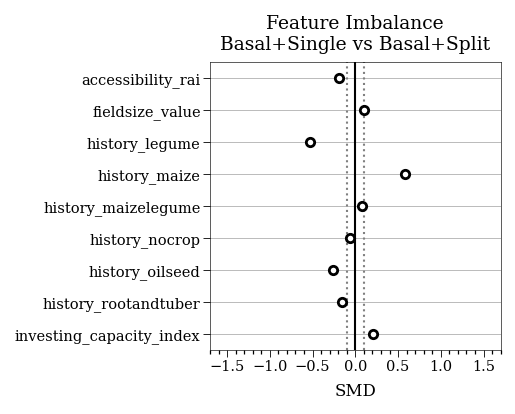

In [99]:
# Check balance in significantly different groups: Basal+Single vs Basal+Split
tmp_df = transformed_data_pstrimmed[balance_cols].copy()
tmp_df['group'] = appl_clusters_df['Cluster name']
tmp_df = tmp_df.loc[transformed_data_pstrimmed.soil_sandy == 0]


fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
love_plot(tmp_df, ax, groups=['Basal+Single', 'Basal+Split'], group_col='group')
ax.set_title(f"Feature Imbalance\nBasal+Single vs Basal+Split")
ax.set_xticks(np.arange(-2, 2, 0.5))
ax.set_xticks(np.arange(-2, 2, 0.1), minor=True)

ax.set_xlabel('SMD')
ax.set_xlim(-1.7, 1.7)


In [100]:
z_test_time_soil = pairwise_ztest(timing_coefs.reset_index(), 'level_0', 'level_1', 'point_estimate', "stderr")
z_test_time_soil

,,,Diff,Zstat,pvalue
level_0,Group1,Group2,,,
Basal+Single,Non-sandy,Sandy,2.811,0.495575,0.620194
Basal+Split,Non-sandy,Sandy,-8.943,-1.428819,0.153056
Basal-Only,Non-sandy,Sandy,-3.342,-0.169039,0.865766
Top-Only,Non-sandy,Sandy,4.899,1.493438,0.135323


In [101]:
z_test_pfertilizer = pairwise_ztest(pfertilizer_coefs.reset_index(), 'level_1', 'level_0', 'point_estimate', "stderr")
z_test_pfertilizer

Diff     Zstat    pvalue
level_1   Group1 Group2                             
Non-sandy DAP    N-Only    0.578  0.171328  0.863966
                 Other-NP -6.353 -1.135082  0.256341
          N-Only Other-NP -6.931 -1.236001  0.216458
Sandy     DAP    N-Only    0.227  0.052892  0.957818
                 Other-NP -1.569 -0.191590  0.848064
          N-Only Other-NP -1.796 -0.236797  0.812814

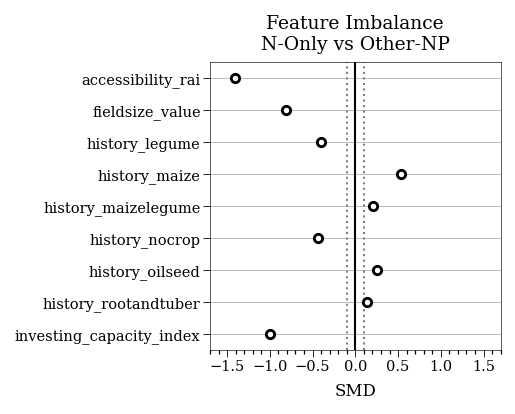

In [102]:
# Check balance in significantly different groups: Basal+Single vs Basal+Split
tmp_df = transformed_data_pstrimmed[balance_cols].copy()
tmp_df['group'] = p_fertilizer_groups
tmp_df = tmp_df.loc[transformed_data_pstrimmed.soil_sandy == 0]

fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
love_plot(tmp_df, ax, groups=['N-Only', 'Other-NP'], group_col='group')
ax.set_title(f"Feature Imbalance\nN-Only vs Other-NP")
ax.set_xticks(np.arange(-2, 2, 0.5))
ax.set_xticks(np.arange(-2, 2, 0.1), minor=True)

ax.set_xlabel('SMD')
ax.set_xlim(-1.7, 1.7)


In [103]:
z_test_legume = pairwise_ztest(legume_coefs.reset_index(), 'level_1', 'level_0', 'point_estimate', "stderr")
z_test_legume

,,,Diff,Zstat,pvalue
level_1,Group1,Group2,,,
Non-sandy,Legume,Non-legume,22.900,3.133569,0.001727
Sandy,Legume,Non-legume,-3.161,-0.531724,0.594917


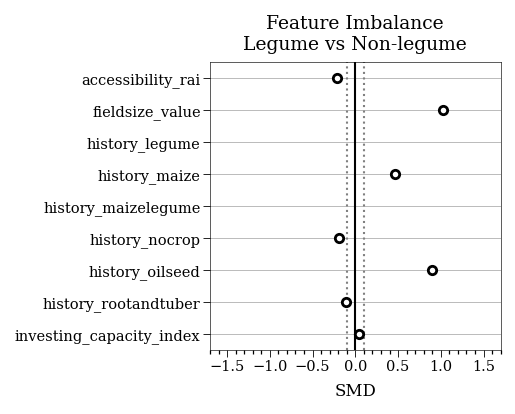

In [104]:
# Check balance in significantly different groups: Basal+Single vs Basal+Split
tmp_df = transformed_data_pstrimmed[balance_cols].copy()
tmp_df['group'] = legume_rotation_groups
tmp_df = tmp_df.loc[transformed_data_pstrimmed.soil_sandy == 0]

fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
love_plot(tmp_df, ax, groups=['Legume', 'Non-Legume'], group_col='group')
ax.set_title(f"Feature Imbalance\nLegume vs Non-legume")
ax.set_xticks(np.arange(-2, 2, 0.5))
ax.set_xticks(np.arange(-2, 2, 0.1), minor=True)

ax.set_xlabel('SMD')
ax.set_xlim(-1.7, 1.7)

In [105]:
(
    data
    .loc[transformed_data_pstrimmed.index]
    .groupby(['soil_sandy', 'history_maizelegume'])
    [[treatment_name, outcome_name]]
    .agg(['mean', 'std'])
)


fertN_total            outcome_prodkgha  \
                                      mean        std             mean   
soil_sandy history_maizelegume                                           
False      False                111.866454  44.138976      4645.944542   
           True                  93.903827  33.161302      2856.083147   
True       False                101.422722  41.146271      4195.007578   
           True                  87.272623  36.778357      3490.425714   

                                             
                                        std  
soil_sandy history_maizelegume               
False      False                1760.261143  
           True                 1578.135845  
True       False                1724.363807  
           True                 1207.034401

Text(0.5, 1.0, 'Common support for the groups')

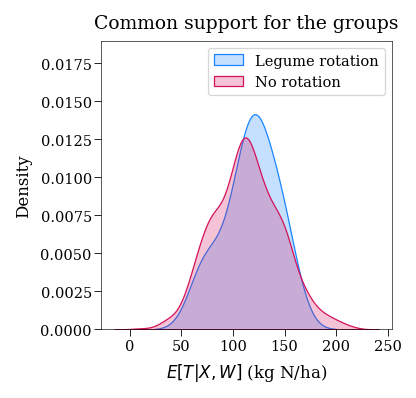

In [106]:
# Check that  
tmp_df = transformed_data.copy()
tmp_df[treatment_name] = data[treatment_name]
tmp_df['ps'] = ps_df['T_pred']
# tmp_df.loc[~tmp_df.soil_sandy.astype(bool)].groupby('history_maizelegume')[treatment_name].describe().T
tmp_df = tmp_df.loc[~tmp_df.soil_sandy.astype(bool)]
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
sns.kdeplot(
    tmp_df.loc[tmp_df.history_maizelegume == 1, 'ps'],
    ax=ax, label='Legume rotation', color='#1A85FF',
    fill=True
)
sns.kdeplot(
    tmp_df.loc[tmp_df.history_maizelegume == 0, 'ps'],
    ax=ax, label='No rotation', color='#D41159',
    fill=True
)
ax.legend()
ax.set_xlabel(r'$E[T|X,W]$'+' (kg N/ha)')
ax.set_ylim(0, 0.019)
ax.set_title("Common support for the groups")

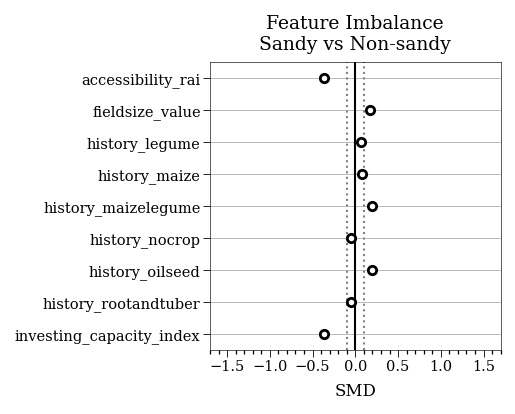

In [107]:
# Check balance in Legume-Maize groups between Sandy and non-sandy
tmp_df = transformed_data_pstrimmed[balance_cols].copy()
tmp_df['group'] = np.where(transformed_data_pstrimmed.soil_sandy.astype(bool), "Sandy", "Non-sandy")

fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
love_plot(tmp_df, ax, groups=['Sandy', 'Non-sandy'], group_col='group')
ax.set_title(f"Feature Imbalance\nSandy vs Non-sandy")
ax.set_xticks(np.arange(-2, 2, 0.5))
ax.set_xticks(np.arange(-2, 2, 0.1), minor=True)

ax.set_xlabel('SMD')
ax.set_xlim(-1.7, 1.7)


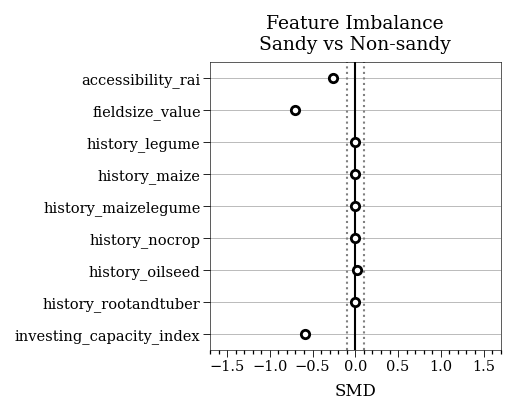

In [108]:
# Check balance in significantly different groups: Basal+Single vs Basal+Split
tmp_df = transformed_data_pstrimmed[balance_cols].copy()
tmp_df['group'] = np.where(transformed_data_pstrimmed.soil_sandy.astype(bool), "Sandy", "Non-sandy")
tmp_df = tmp_df.loc[tmp_df.history_maizelegume == 1]

fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
love_plot(tmp_df, ax, groups=['Sandy', 'Non-sandy'], group_col='group')
ax.set_title(f"Feature Imbalance\nSandy vs Non-sandy")
ax.set_xticks(np.arange(-2, 2, 0.5))
ax.set_xticks(np.arange(-2, 2, 0.1), minor=True)

ax.set_xlabel('SMD')
ax.set_xlim(-1.7, 1.7)


In [109]:
est_order = ['Soil', 'Soil+Rate', 'Soil+Time', 'Soil+P', 'Soil+Legume']
ate_df.loc[(est_order, 'Sandy'), :].astype(float).round(1)

,,Mean,SE,LowerCI,UpperCI,pvalue
Estimate,Soil,,,,,
Soil,Sandy,11.0,2.0,7.1,14.9,0.0
Soil+Rate,Sandy,10.8,2.9,5.2,16.5,0.0
Soil+Time,Sandy,10.8,2.0,6.9,14.7,0.0
Soil+P,Sandy,11.3,1.9,7.6,15.0,0.0
Soil+Legume,Sandy,11.1,2.0,7.2,15.1,0.0


In [110]:
ate_df.loc[(est_order, 'ATE'), :].Mean.mean(), np.sqrt((ate_df.loc[(est_order, 'ATE'), :].astype(float).round(1).SE ** 2).mean())

In [111]:
# Difference for the legume case
legume_coefs.loc[(slice(None), 'Non-sandy'), 'point_estimate'].diff().iloc[1], \
    np.sqrt((legume_coefs.loc[(slice(None), 'Non-sandy'), 'stderr']**2).mean())